In [2]:
import importlib
import pandas as pd
import numpy as np
from helpers import preprocessors as helper
from helpers import plotters
import os
importlib.reload(helper)
from pathlib import Path
from datetime import datetime

In [3]:
Soil_analysis_pd = pd.read_csv('../Soil_Analysis/Al Moutmir - Soil Analysis.csv', low_memory=False)

COLUMNS_OF_INTEREST = ['Sand%', 'Clay%', 'Total_Silt%','Coarse element %', 'pH_water',
                       'CaCo3 active%', 'C.E.C (meq / 100g)',
                       'CE_ext1 / 5 ms / cm', 'Na2O ppm', 'Cl- ppm', 'Na meq / 100g',
                       'C / N ratio', 'Organic matter%', 'Exchangeable K2O ppm',
                       'P2O5 ehangable Olsen ppm', 'MgO ppm', 'CaO ppm', 'Iron ppm DTPA',
                       'Mn ppm DTPA', 'Cu ppm DTPA', 'Zn ppm DTPA', 'B ppm Hot water']

In [4]:
# Create output directory with current date and time in the name
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
OUT_DIR = os.path.join(Path.home(),"CESBIO/AL_Moutmir/Soil_Datasets/", f"soil_dataset_{timestamp}")
os.makedirs(OUT_DIR, exist_ok=True)
print(f"Output directory created: {OUT_DIR}")

Output directory created: /home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251106_121217


In [5]:
Soil_analysis_pd

,Id,Longitude_X,Latitude_Y,Date,depth,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,...,Organic matter%,Exchangeable K2O ppm,P2O5 ehangable Olsen ppm,MgO ppm,CaO ppm,Iron ppm DTPA,Mn ppm DTPA,Cu ppm DTPA,Zn ppm DTPA,B ppm Hot water
0,1,-2.6313,34.8688,31/12/19,0-30 cm,29,43,29,12,16,...,2.3,779,6,930,"11,292",1.0,3.7,0.8,0.4,0.5
1,2,-2.2581,34.9366,31/12/19,0-30 cm,27,49,24,11,14,...,2.4,462,24,"1,905","11,973",7.1,11.8,1.6,1.7,0.6
2,3,-2.3148,34.9535,31/12/19,0-30 cm,24,50,26,12,14,...,2.6,601,12,"2,226","11,379",7.7,11.9,5.6,2.1,0.7
3,4,-2.3435,34.9541,6/12/19,0-30 cm,11,58,31,14,18,...,2.3,719,71,"1,838","7,680",8.2,11.6,3.7,3.5,0.7
4,5,-2.3467,34.9629,6/12/19,0-30 cm,18,52,31,19,12,...,2.1,574,79,"1,674","10,864",7.9,7.4,9.5,9.9,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57329,"57,330",-7.8887,33.2380,21/12/17,0-30 cm,65,15,20,20,NaN,...,1.9,139,72,22,111,86.9,68.5,NaN,0.6,NaN
57330,"57,331",-8.1819,31.2069,11/11/17,0-30 cm,17,26,57,57,NaN,...,6.0,77,59,50,355,90.4,119.1,NaN,6.3,NaN
57331,"57,332",-7.7875,33.2635,11/11/17,0-30 cm,50,24,26,26,NaN,...,2.0,251,124,12,80,98.7,54.7,NaN,0.8,NaN
57332,"57,333",-6.6107,34.0048,12/12/17,0-30 cm,91,3,6,6,NaN,...,0.9,194,48,4,33,134.0,9.4,NaN,1.3,NaN


In [6]:
# Ensure column names are stripped of extra whitespace
Soil_analysis_pd.columns = Soil_analysis_pd.columns.str.strip()
Soil_analysis_pd = Soil_analysis_pd.drop(columns=['Id'], errors='ignore')
print(Soil_analysis_pd.columns)
Soil_analysis_pd.dtypes

Index(['Longitude_X', 'Latitude_Y', 'Date', 'depth', 'Sand%', 'Clay%',
       'Total_Silt%', 'Fine silt%', 'Coarse silt%', 'Coarse element %',
       'pH_water', 'CaCo3%_Total', 'CaCo3 active%', 'C.E.C (meq / 100g)',
       'CE_ext1 / 5 ms / cm', 'Na2O ppm', 'Cl- ppm', 'Na meq / 100g',
       'C / N ratio', 'Organic matter%', 'Exchangeable K2O ppm',
       'P2O5 ehangable Olsen ppm', 'MgO ppm', 'CaO ppm', 'Iron ppm DTPA',
       'Mn ppm DTPA', 'Cu ppm DTPA', 'Zn ppm DTPA', 'B ppm Hot water'],
      dtype='object')


Longitude_X                 float64
Latitude_Y                  float64
Date                         object
depth                        object
Sand%                        object
Clay%                        object
Total_Silt%                  object
Fine silt%                   object
Coarse silt%                 object
Coarse element %             object
pH_water                    float64
CaCo3%_Total                 object
CaCo3 active%                object
C.E.C (meq / 100g)           object
CE_ext1 / 5 ms / cm         float64
Na2O ppm                     object
Cl- ppm                      object
Na meq / 100g               float64
C / N ratio                  object
Organic matter%             float64
Exchangeable K2O ppm         object
P2O5 ehangable Olsen ppm     object
MgO ppm                      object
CaO ppm                      object
Iron ppm DTPA               float64
Mn ppm DTPA                 float64
Cu ppm DTPA                 float64
Zn ppm DTPA                 

In [7]:
def split_depth_range(df, col='depth'):
    # Remove "cm" and whitespace
    df[col] = df[col].str.replace('cm', '', regex=False).str.strip()
    
    # Split into two numeric columns
    depth_split = df[col].str.split('-', expand=True)

    df['depth_from_cm'] = pd.to_numeric(depth_split[0], errors='coerce')
    df['depth_to_cm']   = pd.to_numeric(depth_split[1], errors='coerce')
    df = df.drop(columns=[col])

    return df

Soil_analysis_pd = split_depth_range(Soil_analysis_pd)


In [8]:
# Number of lines before filtering
before_count = len(Soil_analysis_pd)
print(f'Number of lines before filtering: {before_count}')

# Drop columns with any NaN or empty strings
filtered_Soil_analysis_pd = Soil_analysis_pd.dropna(axis=1, how='all')

# Remove rows containing '-' in any column
#filtered_Soil_analysis_pd = filtered_Soil_analysis_pd[~filtered_Soil_analysis_pd.isin(['-']).any(axis=1)]
filtered_Soil_analysis_pd = filtered_Soil_analysis_pd.replace('-', np.nan)

#drop duplicate rows with respect to latitude and longitude
#filtered_Soil_analysis_pd.drop_duplicates(subset=['Latitude_Y', 'Longitude_X'], inplace=True)
filtered_Soil_analysis_pd.drop_duplicates(inplace=True)

# Number of lines after filtering
after_count = len(filtered_Soil_analysis_pd)
print(f'Number of lines after filtering: {after_count}')

# Display the first few rows
print(filtered_Soil_analysis_pd.head())

Number of lines before filtering: 57334
Number of lines after filtering: 52517
   Longitude_X  Latitude_Y      Date Sand% Clay% Total_Silt% Fine silt%  \
0      -2.6313     34.8688  31/12/19    29    43          29         12   
1      -2.2581     34.9366  31/12/19    27    49          24         11   
2      -2.3148     34.9535  31/12/19    24    50          26         12   
3      -2.3435     34.9541   6/12/19    11    58          31         14   
4      -2.3467     34.9629   6/12/19    18    52          31         19   

  Coarse silt% Coarse element %  pH_water  ... P2O5 ehangable Olsen ppm  \
0           16                4       8.5  ...                        6   
1           14                4       8.7  ...                       24   
2           14                6       8.6  ...                       12   
3           18                2       8.4  ...                       71   
4           12                5       8.7  ...                       79   

  MgO ppm CaO ppm  

In [9]:
# Automatically convert inferred types (optional, keeps string/object tidy)
filtered_Soil_analysis_pd = filtered_Soil_analysis_pd.convert_dtypes()

# Define expected column types
column_types = {
    'float': [
        'Longitude_X', 'Latitude_Y', 'pH_water', 'CaCo3%_Total', 
        'CaCo3 active%', 'C.E.C (meq / 100g)', 'CE_ext1 / 5 ms / cm', 
        'Na2O ppm', 'Cl- ppm', 'Na meq / 100g', 'C / N ratio', 
        'Organic matter%', 'MgO ppm', 'CaO ppm', 'Iron ppm DTPA', 
        'Mn ppm DTPA', 'Cu ppm DTPA', 'Zn ppm DTPA', 'B ppm Hot water'
    ],
    'int': [
        'depth_from_cm', 'depth_to_cm', 'Sand%', 'Clay%', 'Total_Silt%', 'Fine silt%', 'Coarse silt%', 
        'Coarse element %', 'Exchangeable K2O ppm', 'P2O5 ehangable Olsen ppm'
    ],
    'datetime': ['Date'],
    'string': ['CA', 'Province', 'Crop', 'Water regim']
}

# Apply conversions
for dtype, cols in column_types.items():
    helper.safe_convert(filtered_Soil_analysis_pd, cols, dtype)

# Optional: Check result
print(filtered_Soil_analysis_pd.dtypes)

Longitude_X                        Float64
Latitude_Y                         Float64
Date                        datetime64[ns]
Sand%                                Int64
Clay%                                Int64
Total_Silt%                          Int64
Fine silt%                           Int64
Coarse silt%                         Int64
Coarse element %                     Int64
pH_water                           Float64
CaCo3%_Total                       Float64
CaCo3 active%                      Float64
C.E.C (meq / 100g)                 Float64
CE_ext1 / 5 ms / cm                Float64
Na2O ppm                             Int64
Cl- ppm                            Float64
Na meq / 100g                      Float64
C / N ratio                        Float64
Organic matter%                    Float64
Exchangeable K2O ppm                 Int64
P2O5 ehangable Olsen ppm             Int64
MgO ppm                              Int64
CaO ppm                              Int64
Iron ppm DT

/home/kmisbah/CESBIO/AL_Moutmir/alMoutmir_Modeling/helpers/preprocessors.py:110: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


In [10]:
import re

def clean_column_name(col):
    col = col.lower()  # lowercase everything
    
    col = col.replace('%', '_pct')  # replace percent sign with pct
    
    col = col.replace('longitude_x', 'lon')  # replace percent sign with pct
    col = col.replace('latitude_y', 'lat')  # replace percent sign with pct

    # Replace anything not a letter or number with underscore
    col = re.sub(r'[^a-z0-9]+', '_', col)

    # Remove leading/trailing underscores
    col = col.strip('_')

    # Ensure column does not start with a digit
    if re.match(r'^\d', col):
        col = f"col_{col}"

    return col

# Apply renaming to your DataFrame
filtered_Soil_analysis_pd.columns = [clean_column_name(c) for c in filtered_Soil_analysis_pd.columns]

print(filtered_Soil_analysis_pd.columns)


Index(['lon', 'lat', 'date', 'sand_pct', 'clay_pct', 'total_silt_pct',
       'fine_silt_pct', 'coarse_silt_pct', 'coarse_element_pct', 'ph_water',
       'caco3_pct_total', 'caco3_active_pct', 'c_e_c_meq_100g',
       'ce_ext1_5_ms_cm', 'na2o_ppm', 'cl_ppm', 'na_meq_100g', 'c_n_ratio',
       'organic_matter_pct', 'exchangeable_k2o_ppm',
       'p2o5_ehangable_olsen_ppm', 'mgo_ppm', 'cao_ppm', 'iron_ppm_dtpa',
       'mn_ppm_dtpa', 'cu_ppm_dtpa', 'zn_ppm_dtpa', 'b_ppm_hot_water',
       'depth_from_cm', 'depth_to_cm'],
      dtype='object')


In [ ]:
# Print number of lines before filtering
before_lines = len(filtered_Soil_analysis_pd)

# Filter: keep all rows where Sand%, Clay%, and Total_Silt% are null,
# or all are non-null and non-negative and sum to 100

mask = (
    filtered_Soil_analysis_pd[['Sand%', 'Clay%', 'Total_Silt%']].isnull().any(axis=1)
    |
    (
        (filtered_Soil_analysis_pd['Sand%'] >= 0)
        & (filtered_Soil_analysis_pd['Clay%'] >= 0)
        & (filtered_Soil_analysis_pd['Total_Silt%'] >= 0)
        & (filtered_Soil_analysis_pd[['Sand%', 'Clay%', 'Total_Silt%']].sum(axis=1) == 100)
    )
)

filtered_Soil_analysis_pd = filtered_Soil_analysis_pd[mask]

# Print number of lines after filtering
after_lines = len(filtered_Soil_analysis_pd)
print(f"Number of lines before: {before_lines}")
print(f"Number of lines after: {after_lines}")


Number of lines before: 49517
Number of lines after: 47713


In [176]:
max_thresholds = {
    'pH_water': 9.5,
    'CaCo3%_Total': 40,
    'CaCo3 active%': 25,
    'C.E.C (meq / 100g)': 200,
    'CE_ext1 / 5 ms / cm': 5,
    'Na2O ppm': 1500,
    'Cl- ppm': 1500,
    'Na meq / 100g': 0.7,
    'C / N ratio': 100,
    'Organic matter%': 6,
    'Exchangeable K2O ppm': 500,
    'P2O5 ehangable Olsen ppm': 100,
    'MgO ppm': 800,
    'CaO ppm': 3000,
    'Iron ppm DTPA': 100,
    'Mn ppm DTPA': 10,
    'Cu ppm DTPA': 15,
    'Zn ppm DTPA': 20,
    'B ppm Hot water': 2
}

In [177]:
# Print number of lines before filtering
before_filter = len(filtered_Soil_analysis_pd)
print(f"Number of lines before threshold filtering: {before_filter}")

# Apply threshold filtering
for col, threshold in max_thresholds.items():
    if col in filtered_Soil_analysis_pd.columns:
        filtered_Soil_analysis_pd = filtered_Soil_analysis_pd[
            (filtered_Soil_analysis_pd[col].isna()) | (filtered_Soil_analysis_pd[col] <= threshold)
        ]

#
after_filter = len(filtered_Soil_analysis_pd)
print(f"Number of lines after threshold filtering: {after_filter}")

Number of lines before threshold filtering: 47713
Number of lines after threshold filtering: 28559


In [178]:
# --- Configuration ---
VALIDATION_RULES = {
    'texture': {
        '>70%': {'ph_max': 7.8, 'caco3_min': 5},       # Calcareous sands
        '60-70%': {'ph_max': 8.2, 'caco3_min': 3},     # Loamy sands
        '<60%': {'ph_max': 8.9}                        # General soils
    },
    'absolute_limits': {
        'ph_absolute_max': 8.9,                        # Sodic soils threshold
        'om_ph_limit': (5, 8.3),                       # OM% >5 and pH >8.3
        'na_limit': 120                                # ppm
    }
}


TEXTURE_CEC = {
    'Sand': (3, 4.0), 'Loamy Sand': (5, 3.8), 'Sandy Loam': (10, 3.5),
    'Loam': (15, 3.2), 'Silt Loam': (18, 3.0), 'Sandy Clay Loam': (20, 2.8),
    'Silty Clay Loam': (25, 2.5), 'Clay Loam': (25, 2.2),
    'Sandy Clay': (30, 2.0), 'Silty Clay': (35, 1.8),
    'Clay': (40, 1.5), 'Unknown': (20, 2.5)
}

CEC_COL = 'C.E.C (meq / 100g)'


# --- Helper Functions ---
def classify_texture(sand, clay, silt):
    if any(pd.isna([sand, clay, silt])):
        return 'Unknown'
    total = sand + clay + silt
    if abs(total - 100) > 1:
        sand = (sand / total) * 100
        clay = (clay / total) * 100
        silt = (silt / total) * 100

    if silt + 1.5*clay < 15:
        return 'Sand'
    elif silt + 1.5*clay >= 15 and silt + 2*clay < 30:
        return 'Loamy Sand'
    elif (clay >= 7 and clay < 20) and sand > 52 and silt + 2*clay >= 30:
        return 'Sandy Loam'
    elif clay < 7 and silt < 50 and silt + 2*clay >= 30:
        return 'Loam'
    elif silt >= 50 and clay < 27:
        return 'Silt Loam'
    elif (clay >= 20 and clay < 35) and silt < 28 and sand > 45:
        return 'Sandy Clay Loam'
    elif clay >= 27 and clay < 40 and sand < 20:
        return 'Silty Clay Loam'
    elif clay >= 27 and clay < 40 and (20 <= sand <= 45):
        return 'Clay Loam'
    elif clay >= 35 and sand > 45:
        return 'Sandy Clay'
    elif clay >= 40 and silt >= 40:
        return 'Silty Clay'
    elif clay >= 40 and sand <= 45 and silt < 40:
        return 'Clay'
    else:
        return 'Unknown'

def calculate_expected_cec(row):
    sand, clay, silt = row.get('Sand%'), row.get('Clay%'), row.get('Total_Silt%')
    if any(pd.isna([sand, clay, silt])):
        return (None, None)
    
    texture = classify_texture(sand, clay, silt)
    base_cec, om_factor = TEXTURE_CEC.get(texture, (20, 2.5))
    om = row.get('Organic matter%')
    if pd.isna(om):
        return (None, None)

    om_contribution = om * om_factor
    expected_min = base_cec * 0.75 + om_contribution
    expected_max = base_cec * 1.25 + om_contribution
    abs_min = max(1, expected_min * 0.7)
    abs_max = expected_max * 1.3
    return (abs_min, abs_max)

def validate_row(row):
    """Return True if row violates any rules (ignoring NAs)."""
    sand = row.get('Sand%')
    ph = row.get('pH_water')
    caco3 = row.get('CaCo3%_Total')
    om = row.get('Organic matter%')
    na_meq = row.get('Na meq / 100g')
    cec = row.get(CEC_COL)
    
    # Texture rule
    if pd.notna(sand) and pd.notna(ph):
        if sand > 70:
            if ph > VALIDATION_RULES['texture']['>70%']['ph_max'] and pd.notna(caco3):
                if caco3 < VALIDATION_RULES['texture']['>70%']['caco3_min']:
                    return True
        elif 60 <= sand <= 70:
            if ph > VALIDATION_RULES['texture']['60-70%']['ph_max'] and pd.notna(caco3):
                if caco3 < VALIDATION_RULES['texture']['60-70%']['caco3_min']:
                    return True
        else:
            if ph > VALIDATION_RULES['texture']['<60%']['ph_max']:
                return True

    # Absolute_pH max
    if pd.notna(ph) and ph > VALIDATION_RULES['absolute_limits']['ph_absolute_max']:
        return True

    # OM-pH paradox
    om_limit, ph_limit = VALIDATION_RULES['absolute_limits']['om_ph_limit']
    if pd.notna(om) and pd.notna(ph):
        if om > om_limit and ph > ph_limit:
            return True

    # Sodium hazard (convert meq to ppm)
    if pd.notna(ph) and pd.notna(na_meq):
        na_ppm = na_meq * 23 / 10
        if ph > 8.5 and na_ppm > VALIDATION_RULES['absolute_limits']['na_limit']:
            return True

    # CEC validation
    if pd.notna(cec):
        min_cec, max_cec = calculate_expected_cec(row)
        if min_cec is not None and max_cec is not None:
            if not (min_cec <= cec <= max_cec):
                return True

    return False


In [ ]:
# Print total rows before filtering
total_rows_before = len(filtered_Soil_analysis_pd)
print(f"Total rows before filtering: {total_rows_before}")

# Apply validation function
filtered_Soil_analysis_pd['invalid'] = filtered_Soil_analysis_pd.apply(validate_row, axis=1)

# Keep only conforming rows (where 'invalid' is False)
filtered_Soil_analysis_pd_conforming = filtered_Soil_analysis_pd[filtered_Soil_analysis_pd['invalid'] == False].copy()

# Print total rows after filtering
total_rows_after = len(filtered_Soil_analysis_pd_conforming)
print(f"Total rows after filtering: {total_rows_after}")

# Drop the temporary 'invalid' column
filtered_Soil_analysis_pd_conforming.drop(columns='invalid', inplace=True)

Total rows before filtering: 28559
Total rows after filtering: 27165


In [ ]:
filtered_Soil_analysis_pd = filtered_Soil_analysis_pd_conforming.copy()

In [11]:
# Export the describe() output to a CSV file on the desktop
describe_output = filtered_Soil_analysis_pd.describe()
describe_output.to_csv(os.path.join(OUT_DIR, 'filtered_Soil_analysis_describe.csv'))
filtered_Soil_analysis_pd.to_csv(os.path.join(OUT_DIR,'Morocco_soil_analysis_filtered.csv'), index=False)

In [44]:
filtered_Soil_analysis_pd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52517 entries, 0 to 57333
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   lon                       52517 non-null  Float64       
 1   lat                       52517 non-null  Float64       
 2   date                      52517 non-null  datetime64[ns]
 3   sand_pct                  18058 non-null  Int64         
 4   clay_pct                  17994 non-null  Int64         
 5   total_silt_pct            18227 non-null  Int64         
 6   fine_silt_pct             18225 non-null  Int64         
 7   coarse_silt_pct           15138 non-null  Int64         
 8   coarse_element_pct        11465 non-null  Int64         
 9   ph_water                  52517 non-null  Float64       
 10  caco3_pct_total           19895 non-null  Float64       
 11  caco3_active_pct          15819 non-null  Float64       
 12  c_e_c_meq_100g         

In [ ]:
import uuid
import pandas as pd
from sqlalchemy.dialects.postgresql import UUID as PG_UUID
from sqlalchemy import create_engine, Column, Integer, String, Float, text, DateTime
from geoalchemy2 import Geometry, WKTElement
from sqlalchemy.orm import declarative_base, Session, sessionmaker

# ---------- CONFIG ----------
PG_USER = "devuser"
PG_PASS = "devpassword"
PG_HOST = "localhost"
PG_PORT = "5432"
TARGET_DB = "almoutmir_db"  # database to ensure exists
# ----------------------------

# Convert lon/lat to geometry Points (WGS84 - EPSG:4326)
filtered_Soil_analysis_pd['geom'] = filtered_Soil_analysis_pd.apply(
    lambda row: WKTElement(f"POINT({row['lon']} {row['lat']})", srid=4326), axis=1
)

# --- Connect to Postgres and create new database ---
admin_engine = create_engine(
    f"postgresql+psycopg://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/postgres",
    isolation_level="AUTOCOMMIT",
    plugins=["geoalchemy2"]
)

with admin_engine.connect() as conn:
    conn.execute(text(f"""
        SELECT pg_terminate_backend(pid)
        FROM pg_stat_activity
        WHERE datname = :db
          AND pid <> pg_backend_pid();
    """), {"db": TARGET_DB})

    conn.execute(text(f"DROP DATABASE IF EXISTS {TARGET_DB};"))
    print("Dropped existing DB")
    conn.execute(text(f"CREATE DATABASE {TARGET_DB};"))
    print("Created fresh DB")

# --- Connect to new DB and enable PostGIS ---
engine = create_engine(
    f"postgresql+psycopg://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{TARGET_DB}",
    isolation_level="AUTOCOMMIT",
    plugins=["geoalchemy2"]
)

with engine.connect() as conn:
    conn.execute(text("CREATE EXTENSION IF NOT EXISTS postgis;"))
    print("PostGIS enabled")

# --- Define ORM model ---
Base = declarative_base()

dtype_map = {
    "Int64": Integer,
    "Float64": Float,
    "datetime64[ns]": DateTime,
    "object": String,
    "bool": Integer,
}
cols = {
    "id": Column(PG_UUID(as_uuid=True), default=uuid.uuid4, unique=True, nullable=False, primary_key=True),
    "geom": Column(Geometry("POINT", srid=4326), nullable=False),
}

for col in filtered_Soil_analysis_pd.columns:
    if col.lower() not in ("lat", "lon", "geom"):
        sql_type = dtype_map.get(str(filtered_Soil_analysis_pd[col].dtype), String)
        cols[col] = Column(sql_type)

# --- Create table ---
SoilProperty = type("SoilProperty", (Base,), dict(__tablename__="soil_properties", **cols))
SoilProperty.__table__.drop(engine, checkfirst=True)
SoilProperty.__table__.create(engine)
print("Table created")

# --- Insert DataFrame rows ---
records = []
for _, row in filtered_Soil_analysis_pd.iterrows():
    row_data = {col: (None if pd.isna(row[col]) else row[col]) for col in filtered_Soil_analysis_pd.columns}
    record = SoilProperty(
        geom=row.geom,
        **{k: v for k, v in row_data.items() if k not in ("lat", "lon", "geom")}
    )
    records.append(record)

Session = sessionmaker(bind=engine)
session = Session()
session.add_all(records)
session.commit()

# --- Add spatial index ---
with engine.connect() as conn:
    conn.execute(text("UPDATE soil_properties SET geom = ST_MakeValid(geom) WHERE NOT ST_IsValid(geom);"))
    conn.commit()

with engine.connect() as conn:
    conn.execute(text(
        "CREATE INDEX IF NOT EXISTS idx_soil_geom ON soil_properties USING GIST (geom);"
    ))
    print("Spatial index created")x

✅ Dropped existing DB
✅ Created fresh DB
✅ PostGIS enabled
✅ Table created
✅ Spatial index created


In [1]:
import os
import uuid
import pandas as pd
import geopandas as gpd
from shapely import wkt

# Cell 18: read a CSV, convert to GeoDataFrame if possible, add a UUID column, and export CSV with "_uuid" suffix

# EDIT this path to point to your CSV
INPUT_CSV = "/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_soil_analysis_filtered.csv"

# Read CSV
df = pd.read_csv(INPUT_CSV)

# Attempt to infer lon/lat columns (case-insensitive)
lon_col = next((c for c in df.columns if c.lower() in ("lon", "longitude", "longitude_x", "long")), None)
lat_col = next((c for c in df.columns if c.lower() in ("lat", "latitude", "latitude_y", "lat_y")), None)

if lon_col and lat_col:
    gdf = gpd.GeoDataFrame(df.copy(), geometry=gpd.points_from_xy(df[lon_col], df[lat_col]), crs="EPSG:4326")
elif "geometry" in df.columns:
    # assume WKT strings in 'geometry' column
    try:
        geom = df["geometry"].apply(lambda v: wkt.loads(v) if pd.notna(v) else None)
        gdf = gpd.GeoDataFrame(df.copy(), geometry=geom, crs="EPSG:4326")
    except Exception:
        gdf = gpd.GeoDataFrame(df.copy())
else:
    gdf = gpd.GeoDataFrame(df.copy())

# Add UUID column (if exists, will be overwritten)
gdf["uuid"] = [uuid.uuid4() for _ in range(len(gdf))]

# Export to CSV with "_uuid" suffix (drop geometry column to keep CSV simple)
base, ext = os.path.splitext(INPUT_CSV)
OUT_CSV = f"{base}_uuid{ext}"
gdf.drop(columns="geometry", errors="ignore").to_csv(OUT_CSV, index=False)

print(f"Saved {len(gdf)} rows with UUIDs to: {OUT_CSV}")

Saved 52517 rows with UUIDs to: /home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_soil_analysis_filtered_uuid.csv


In [3]:
import os
import uuid
import pandas as pd
import geopandas as gpd
from shapely import wkt


# -------------------------------------------------------
# Helper: Load any CSV as GeoDataFrame (auto-detect geometry)
# -------------------------------------------------------

def load_csv_as_gdf(path):
    df = pd.read_csv(path)

    # Attempt lon/lat detection
    lon_col = next((c for c in df.columns if c.lower() in ("lon", "longitude", "longitude_x", "long")), None)
    lat_col = next((c for c in df.columns if c.lower() in ("lat", "latitude", "latitude_y", "lat_y")), None)

    if lon_col and lat_col:
        gdf = gpd.GeoDataFrame(df.copy(), geometry=gpd.points_from_xy(df[lon_col], df[lat_col]), crs="EPSG:4326")
    elif "geometry" in df.columns:
        try:
            geom = df["geometry"].apply(lambda v: wkt.loads(v) if pd.notna(v) else None)
            gdf = gpd.GeoDataFrame(df.copy(), geometry=geom, crs="EPSG:4326")
        except Exception:
            gdf = gpd.GeoDataFrame(df.copy())
    else:
        gdf = gpd.GeoDataFrame(df.copy())

    return gdf


# -------------------------------------------------------
# STEP 1 — Load FIRST CSV, assign UUIDs, export with "_uuid"
# -------------------------------------------------------

INPUT_CSV_1 = "/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_soil_analysis_filtered_uuid.csv"

gdf1 = load_csv_as_gdf(INPUT_CSV_1)
gdf1["organic_matter_g_kg"] = gdf1["organic_matter_pct"]*10

print(f"[1] Loaded first dataset with {len(gdf1)} rows.")


# -------------------------------------------------------
# STEP 2 — Load SECOND CSV as GeoDataFrame
# -------------------------------------------------------

INPUT_CSV_2 = "/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_covariates_uuid_V2_0.csv"

gdf2 = load_csv_as_gdf(INPUT_CSV_2)

if "uuid" not in gdf2.columns:
    raise ValueError("Second CSV does not contain column 'uuid' — cannot merge.")


print(f"[2] Loaded second dataset with {len(gdf2)} rows.")


# -------------------------------------------------------
# STEP 3 — Merge on UUID
# -------------------------------------------------------

merged = gdf1.merge(gdf2, on="uuid", how="inner", suffixes=("_file1", "_file2"))

print(f"[3] Merged rows: {len(merged)}")


# -------------------------------------------------------
# STEP 4 — Export merged file
# -------------------------------------------------------

# CSV output (geometry removed)
base, ext = os.path.splitext(INPUT_CSV_1)
MERGED_CSV = f"{base}_merged_V2_0{ext}"
merged.drop(columns="geometry", errors="ignore").to_csv(MERGED_CSV, index=False)
print(f"[4] Saved merged CSV → {MERGED_CSV}")

[1] Loaded first dataset with 52517 rows.
[2] Loaded second dataset with 51374 rows.
[3] Merged rows: 51374
[4] Saved merged CSV → /home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_soil_analysis_filtered_uuid_merged_V2_0.csv


In [10]:
gdf2.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 51422 entries, 0 to 51421
Data columns (total 40 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   system:index   51422 non-null  object  
 1   Aridity_Index  51422 non-null  float64 
 2   ET             51422 non-null  float64 
 3   Elevation      51422 non-null  int64   
 4   GPP            51422 non-null  float64 
 5   LST            51422 non-null  float64 
 6   NDVI           51422 non-null  float64 
 7   S2_B11         51422 non-null  float64 
 8   S2_B12         51422 non-null  float64 
 9   S2_B2          51422 non-null  float64 
 10  S2_B3          51422 non-null  float64 
 11  S2_B4          51422 non-null  float64 
 12  S2_B8          51422 non-null  float64 
 13  SU_WRB1_PH     51422 non-null  object  
 14  Slope          51422 non-null  int64   
 15  TWI            51422 non-null  float64 
 16  bio01          51422 non-null  float64 
 17  bio02          51422 no

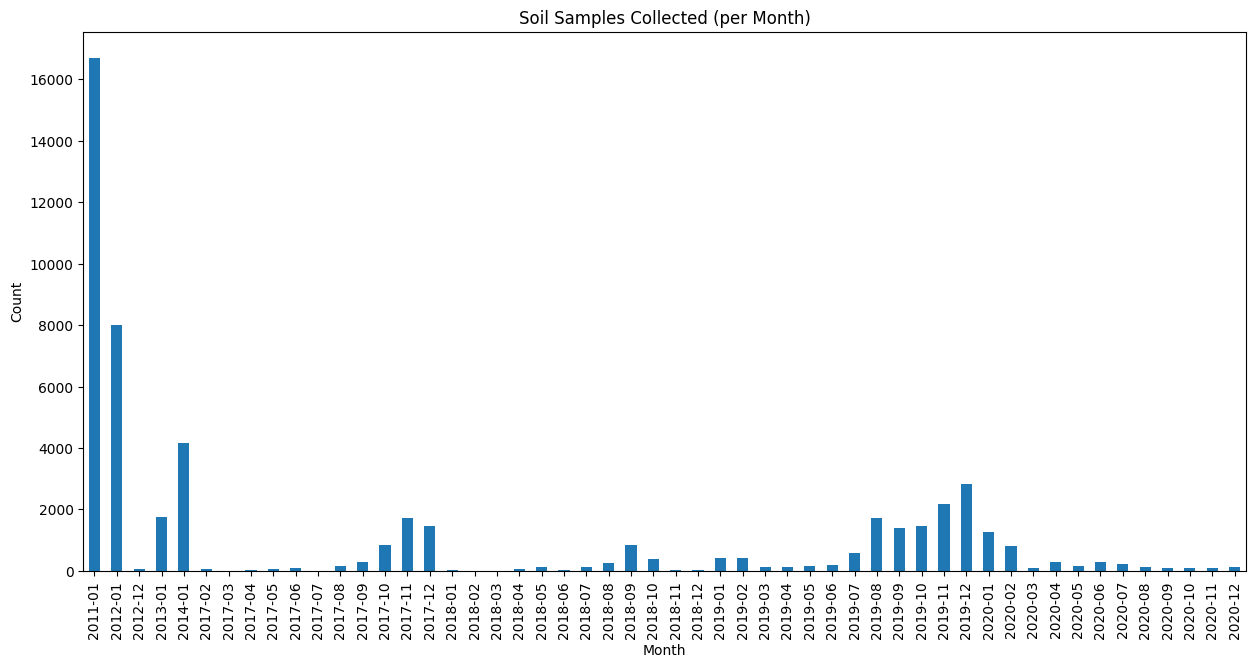

In [12]:
import matplotlib.pyplot as plt

# Aggregate by month
filtered_Soil_analysis_pd['month'] = filtered_Soil_analysis_pd['date'].dt.to_period('M')
monthly_counts = filtered_Soil_analysis_pd['month'].value_counts().sort_index()

# Plot the barplot
plt.figure(figsize=(15, 7))
monthly_counts.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Soil Samples Collected (per Month)')
plt.show()

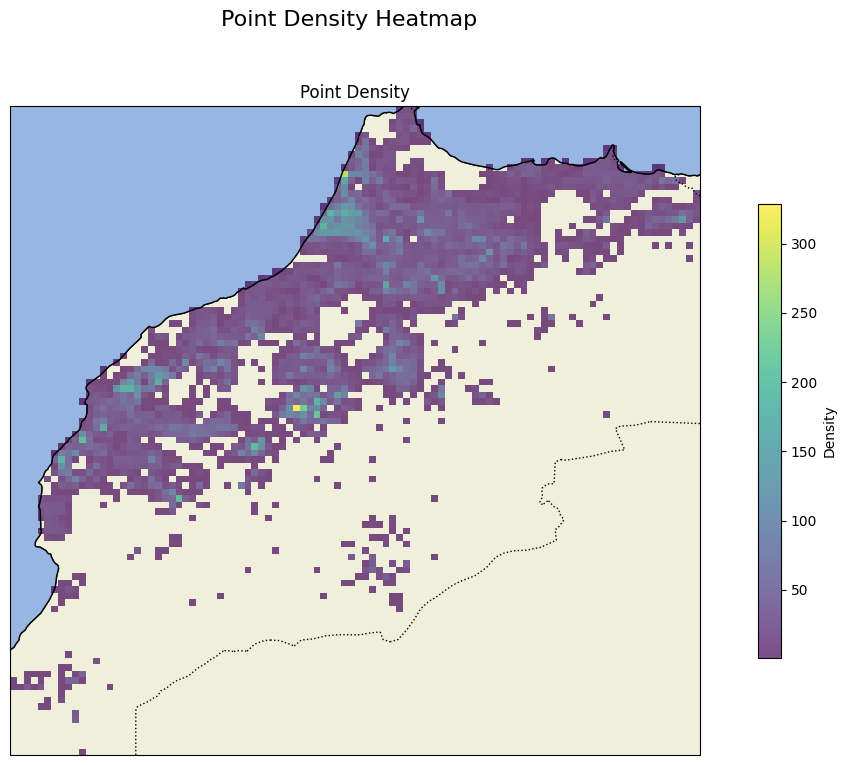

In [15]:
plotters.plot_density_heatmap(filtered_Soil_analysis_pd, single_plot=True, colorbar_mode='continuous', lon_col='lon', lat_col='lat')

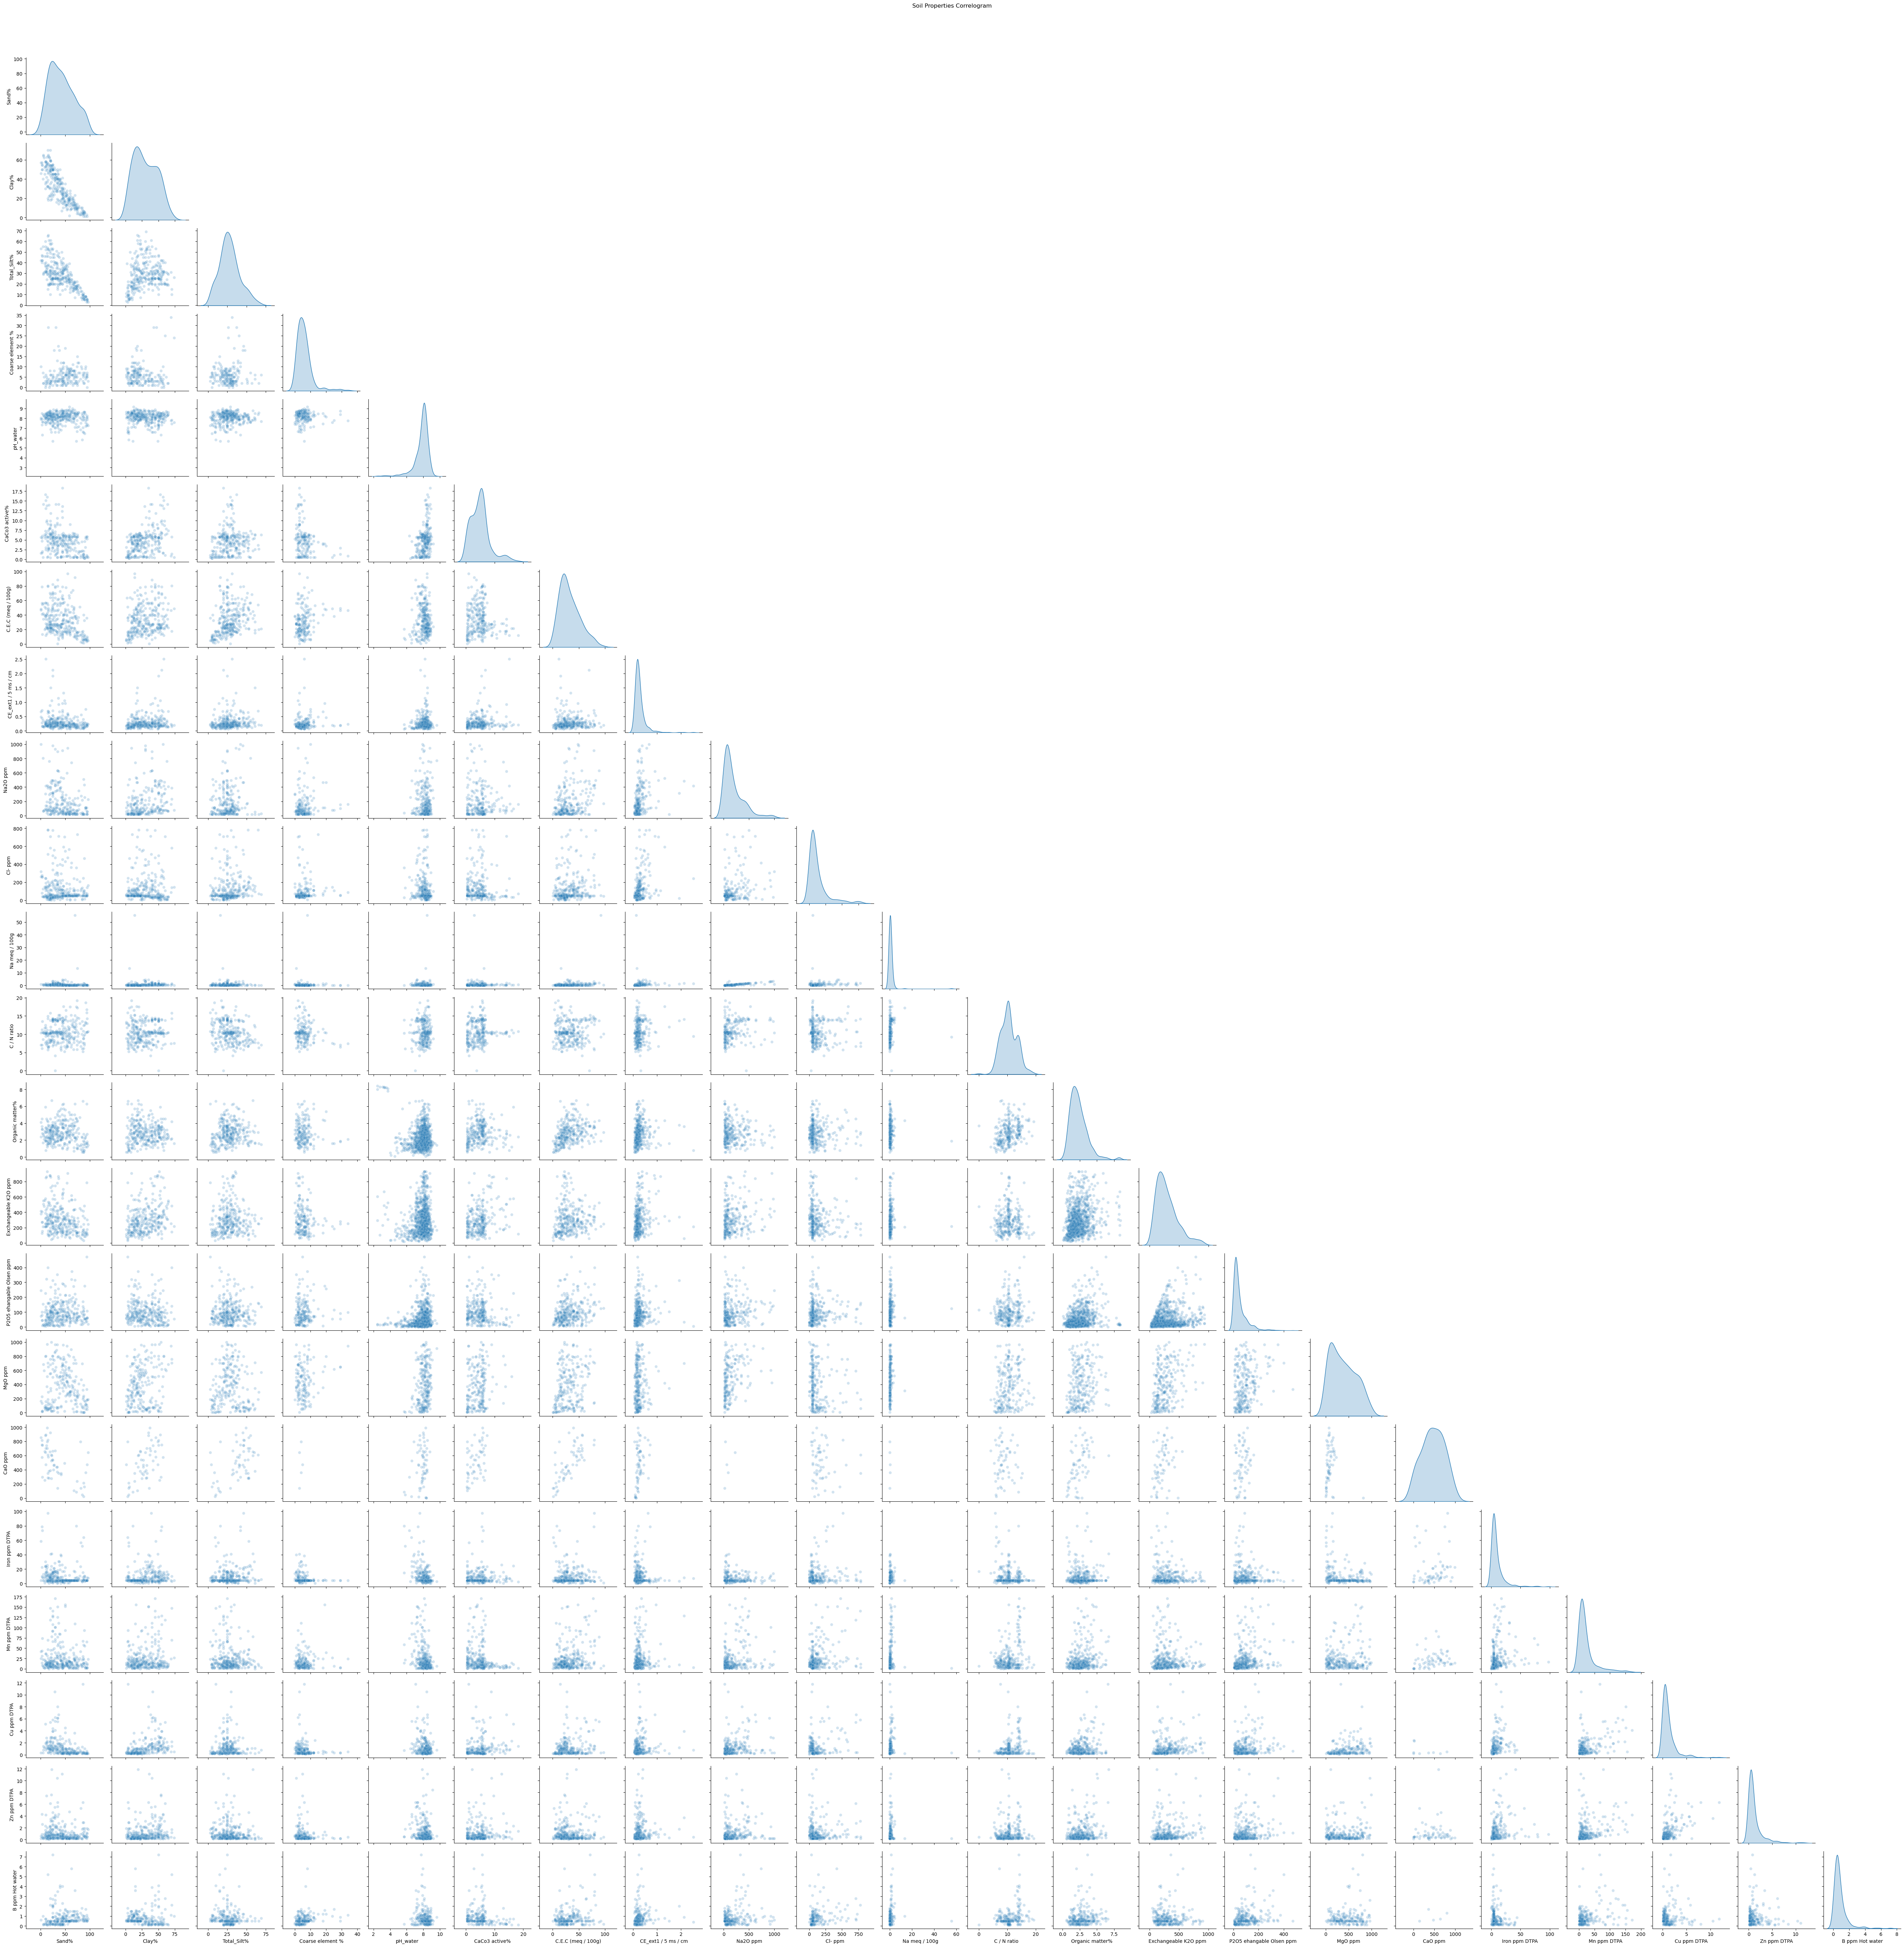

In [239]:
plotters.plot_correlogram(filtered_Soil_analysis_pd, COLUMNS_OF_INTEREST, title='Soil Properties Correlogram')

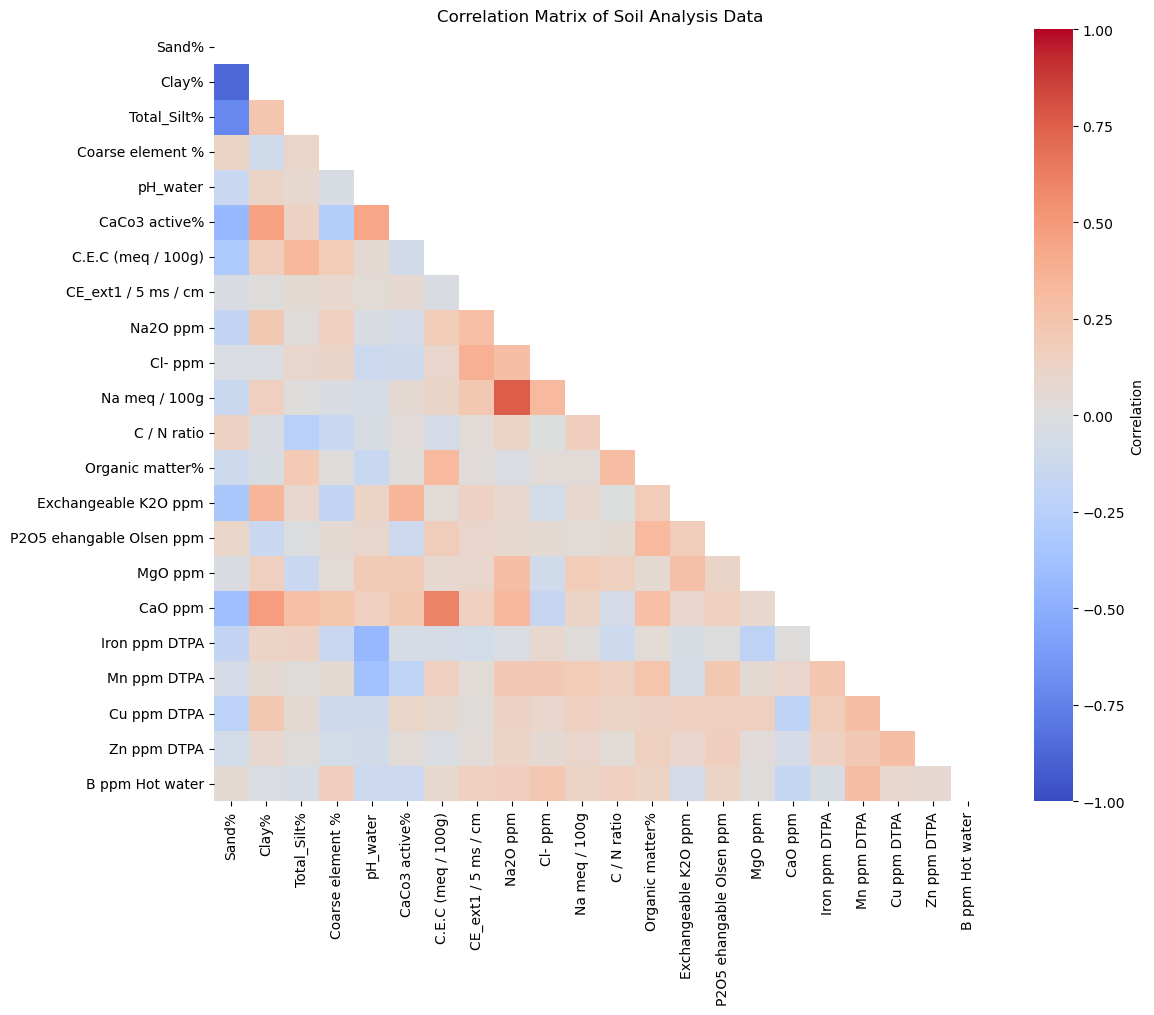

In [240]:
plotters.plot_correlation_heatmap(filtered_Soil_analysis_pd, COLUMNS_OF_INTEREST, 'Correlation Matrix of Soil Analysis Data')


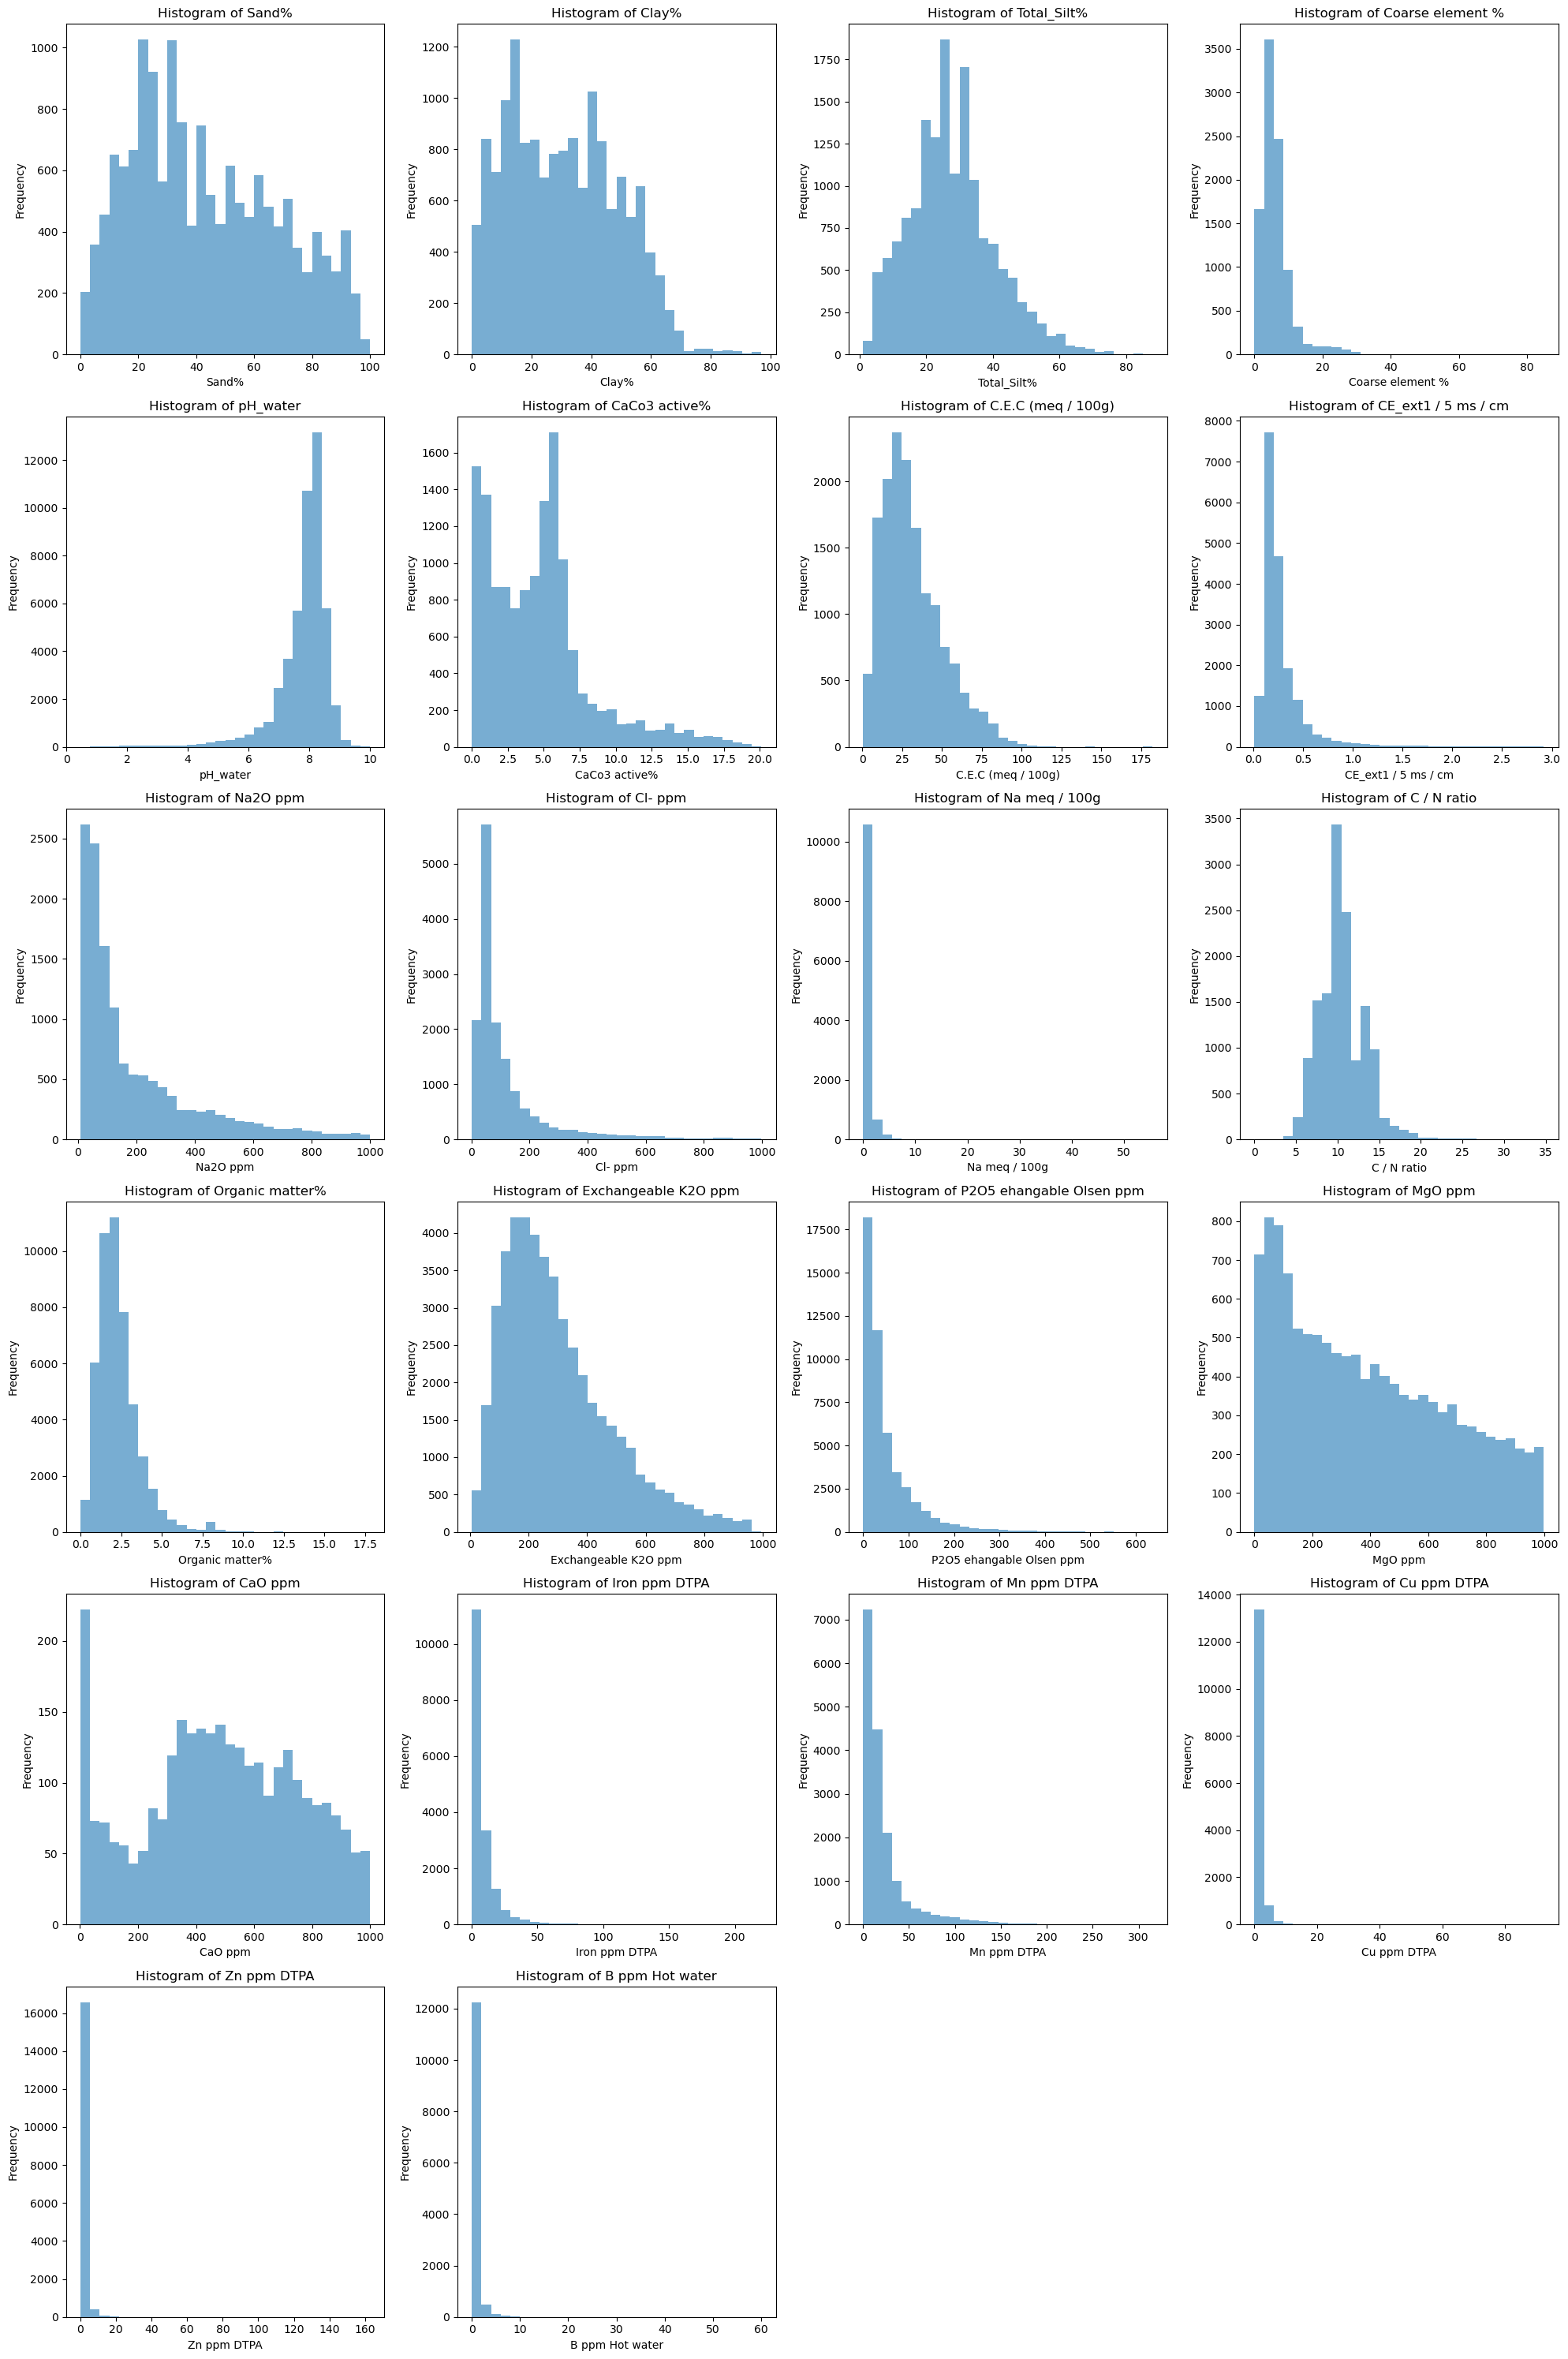

In [241]:
plotters.plot_multiple_datasets(filtered_Soil_analysis_pd, COLUMNS_OF_INTEREST, kind='hist', bins=30)

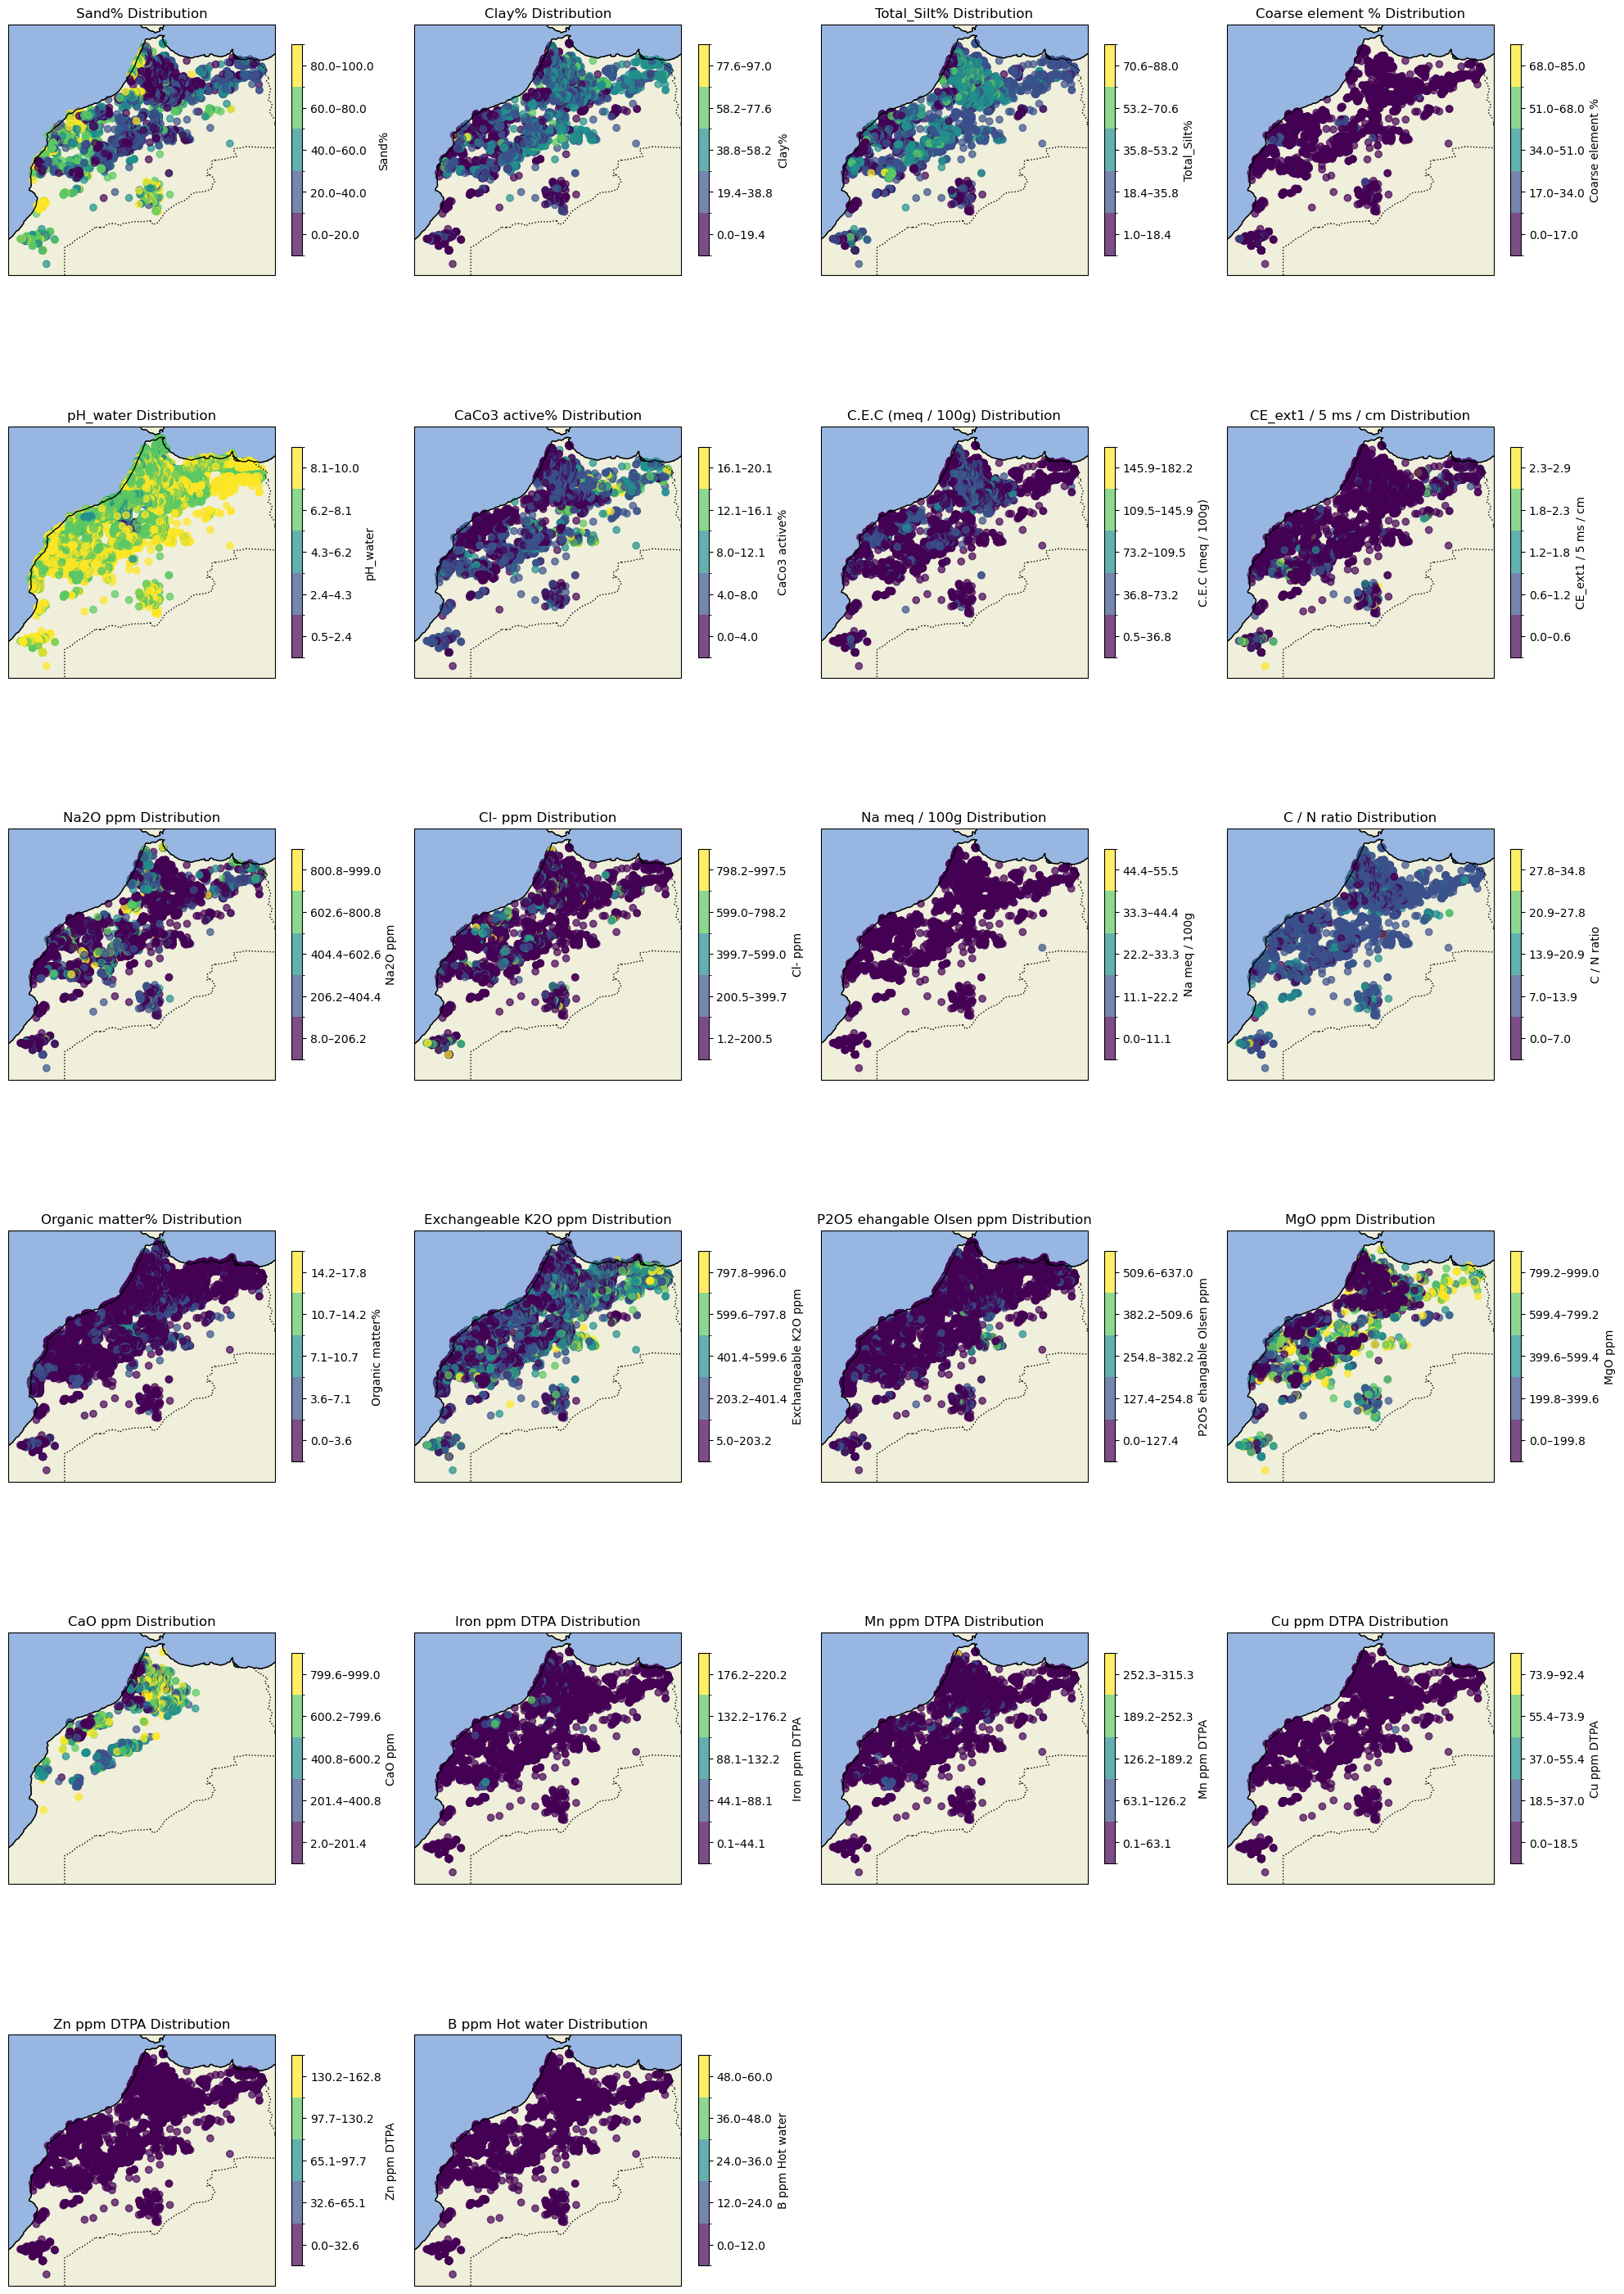

In [242]:
plotters.plot_soil_maps(filtered_Soil_analysis_pd, COLUMNS_OF_INTEREST, group_colormap=True)

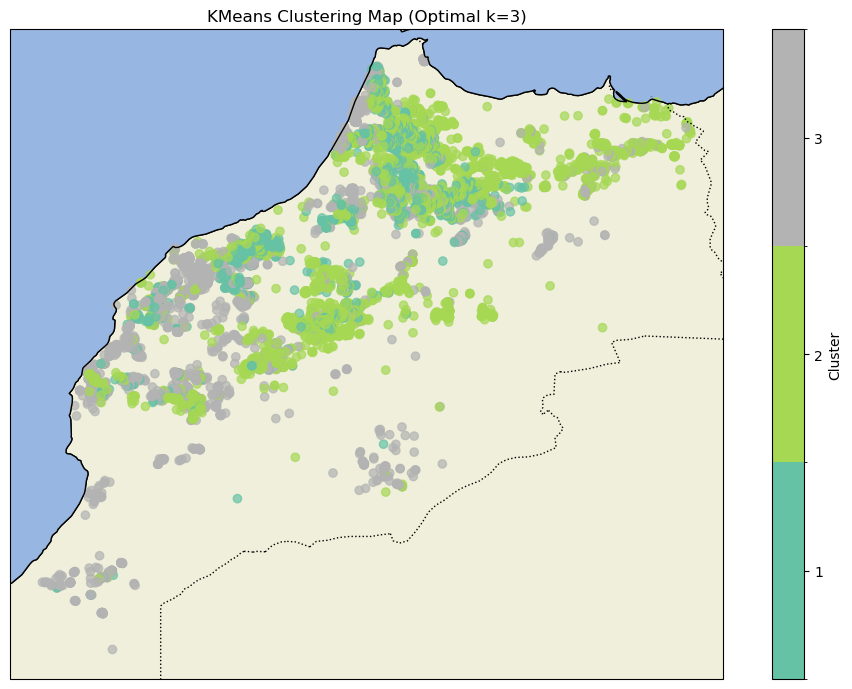

In [243]:
helper.kmeans_clustering_map(filtered_Soil_analysis_pd, feature_cols=['Sand%', 'Clay%', 'Total_Silt%',
                       'CaCo3 active%', 'C.E.C (meq / 100g)', 'Organic matter%'], cmap='Set2', show_cluster_labels=False)


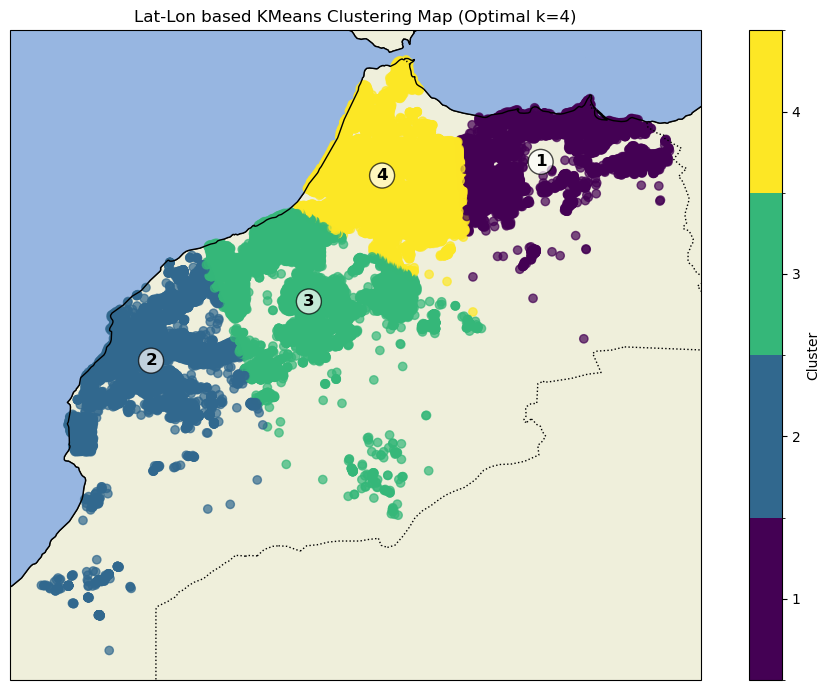

In [244]:
helper.kmeans_clustering_map(filtered_Soil_analysis_pd, feature_cols=['Longitude_X', 'Latitude_Y'], cmap='viridis', title='Lat-Lon based KMeans Clustering Map')

In [191]:
latlon_clustered= helper.kmeans_clustering_map(filtered_Soil_analysis_pd, feature_cols=['Longitude_X', 'Latitude_Y'], show_map=False, return_df=True)

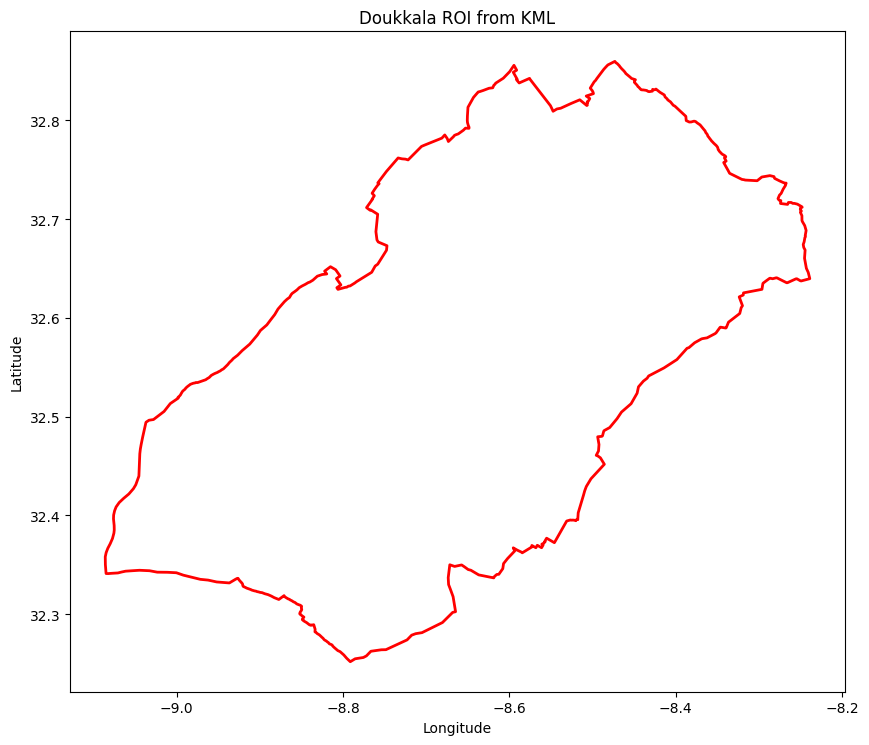

In [13]:
import geopandas as gpd

import matplotlib.pyplot as plt

# Read the KML file (layer name is usually 'Placemark' for KMLs)
kml_path = os.path.join(Path.home(), 'CESBIO/ROI/PRS_prospection/Doukkala_ROI.kml')
gdf = gpd.read_file(kml_path, driver='KML')

# Plot the geometry
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)
ax.set_title('Doukkala ROI from KML')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

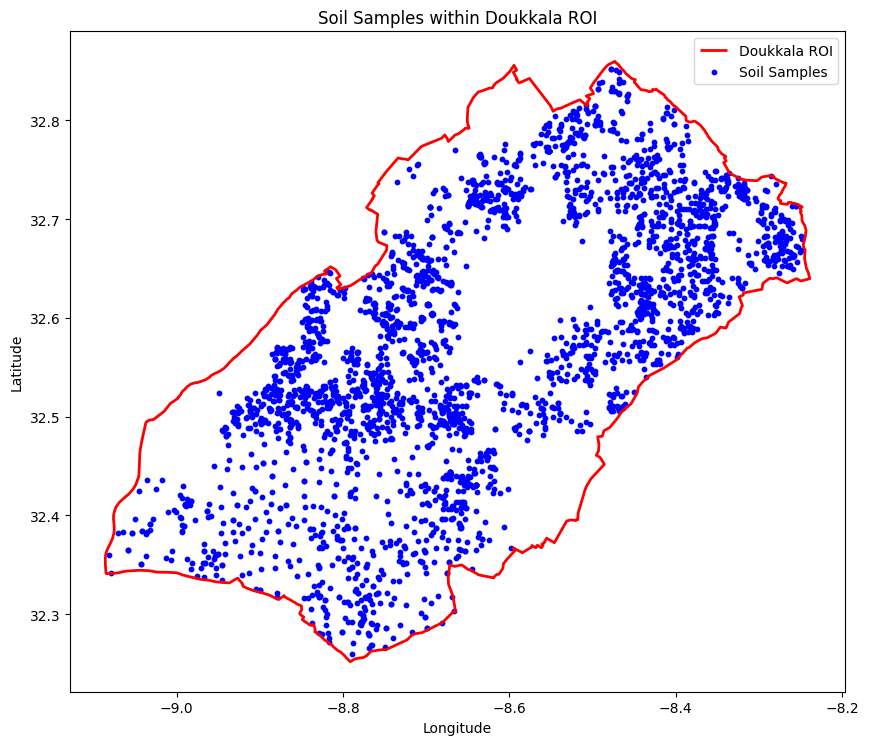

In [14]:
from shapely.geometry import Point

# Create a GeoDataFrame from filtered_Soil_analysis_pd
points_gdf = gpd.GeoDataFrame(
    filtered_Soil_analysis_pd,
    geometry=[Point(xy) for xy in zip(filtered_Soil_analysis_pd['lon'], filtered_Soil_analysis_pd['lat'])],
    crs=gdf.crs
)

# Spatial join: keep only points within the gdf geometry
doukkala_Soil_analysis_pd = points_gdf[points_gdf.within(gdf.geometry.union_all())].copy()

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf.boundary.plot(ax=ax, edgecolor='red', linewidth=2, label='Doukkala ROI')
doukkala_Soil_analysis_pd.plot(ax=ax, color='blue', markersize=10, label='Soil Samples')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Soil Samples within Doukkala ROI')
plt.legend()
plt.show()

In [16]:
doukkala_Soil_analysis_pd.to_csv(os.path.join(OUT_DIR,'doukkala_soil_analysis.csv'), index=False)

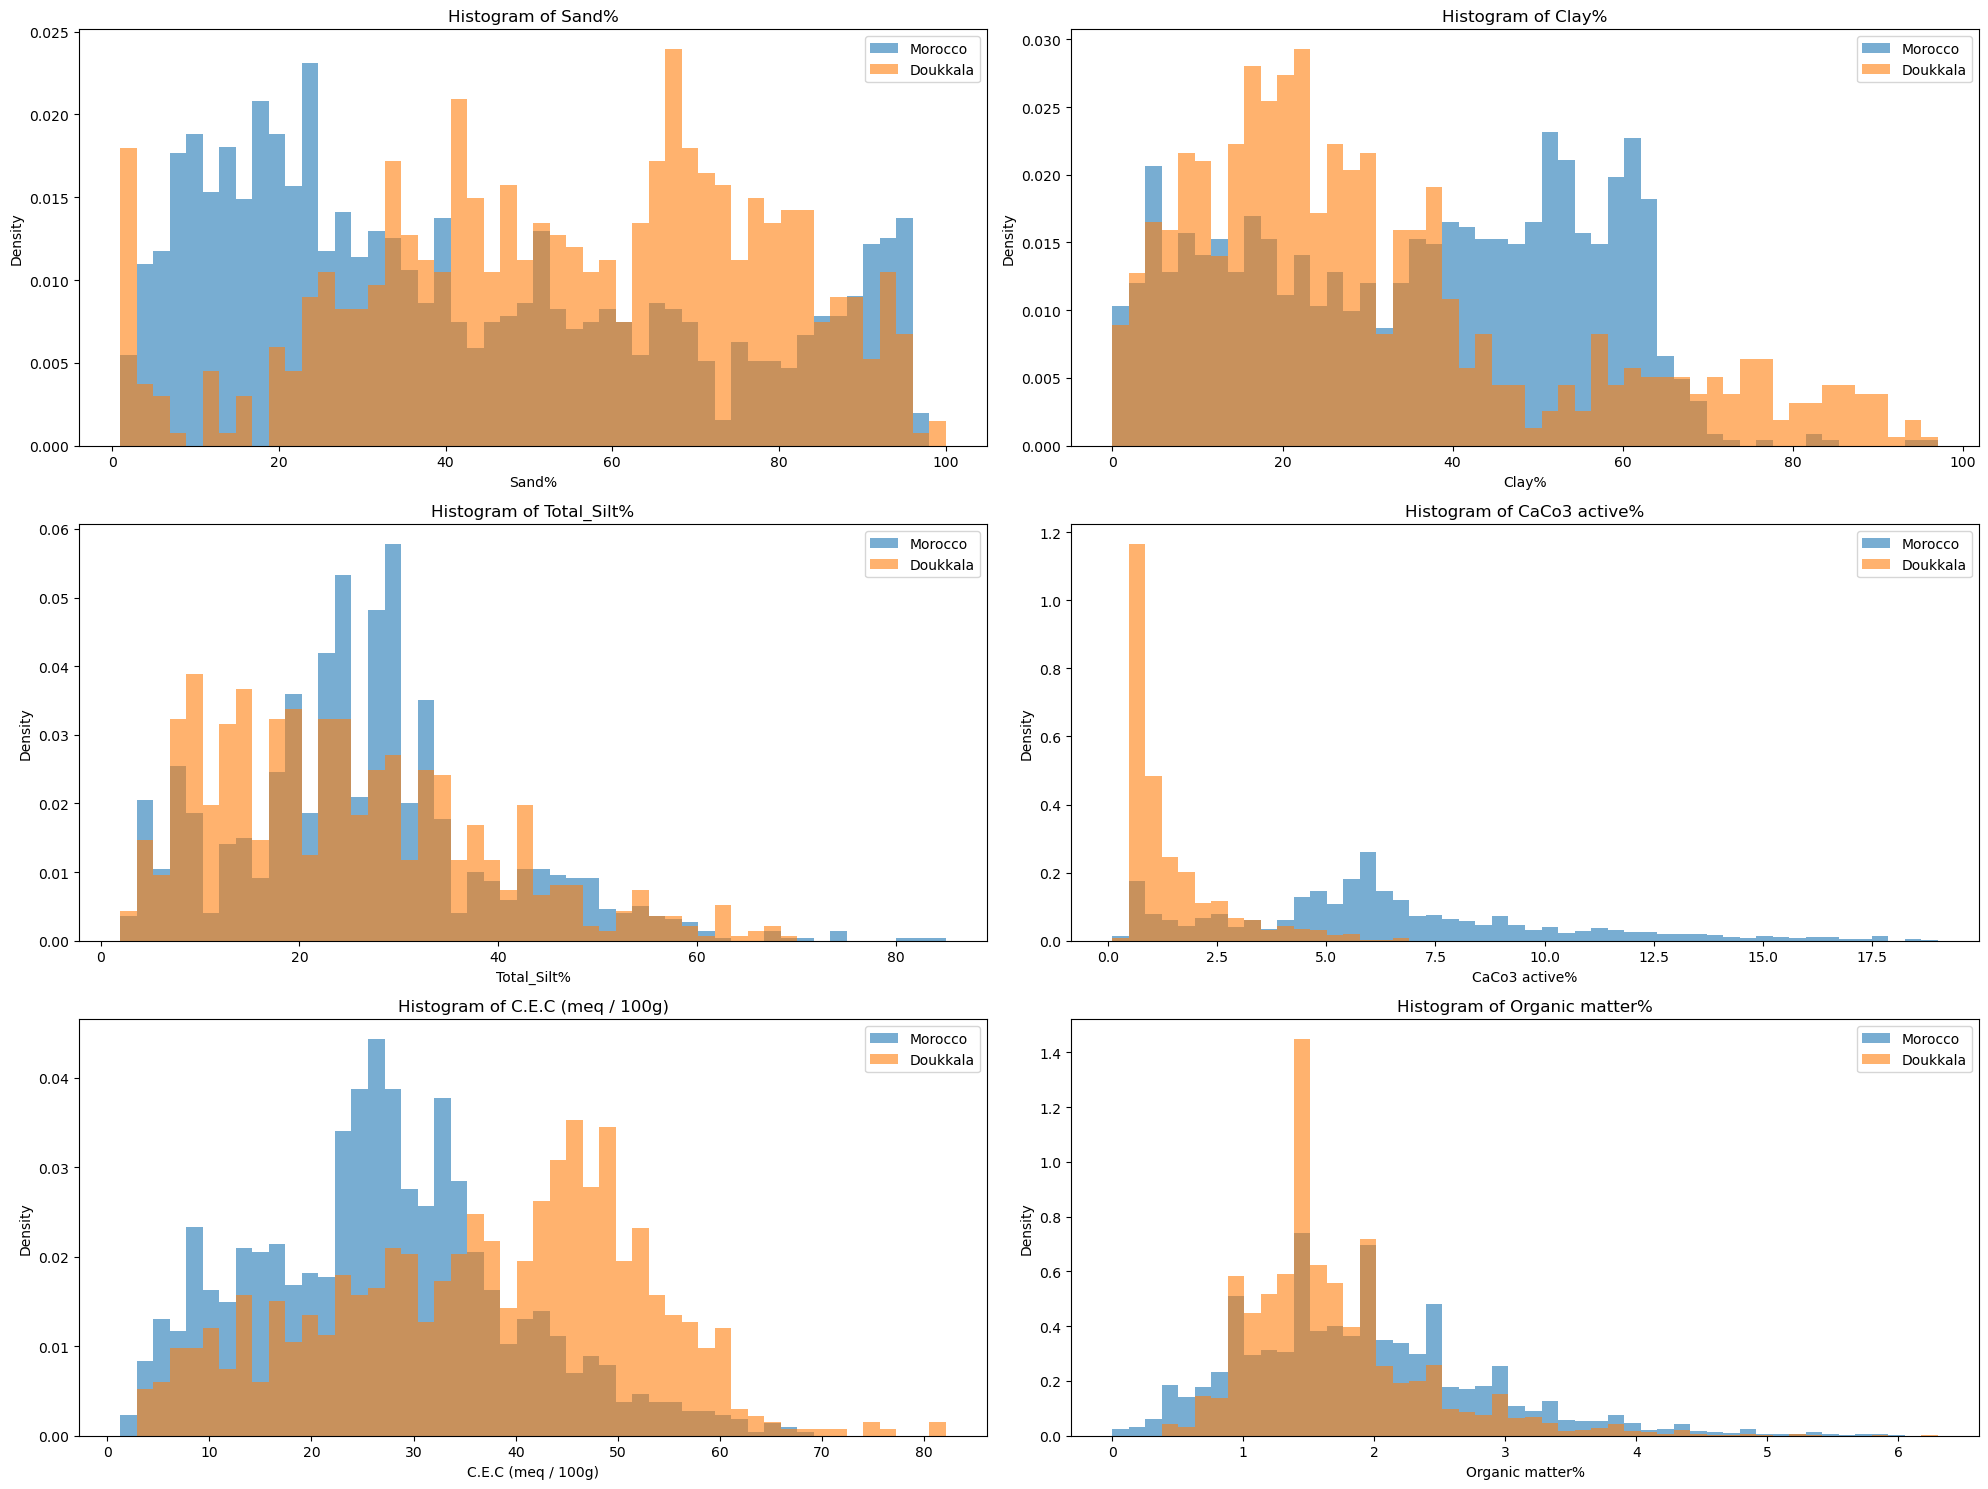

In [248]:
plotters.plot_multiple_datasets(
    dfs=[restof_morocco_Soil_analysis_pd, doukkala_Soil_analysis_pd],
    columns=['Sand%', 'Clay%', 'Total_Silt%',
                       'CaCo3 active%', 'C.E.C (meq / 100g)', 'Organic matter%'],
    dataset_labels=['Morocco', 'Doukkala'],
    kind='hist',
    bins=50 ,ncols=2)

In [22]:
import os
import pyproj # pyproj has a utility to find its data directory

pyproj.datadir.get_data_dir()

'/home/kmisbah/CESBIO/AL_Moutmir/alMoutmir_Modeling/.pixi/envs/default/lib/python3.12/site-packages/pyproj/proj_dir/share/proj'

In [18]:
importlib.reload(helper)
image_path = os.path.join(Path.home(), "CESBIO/PRS Preprocessing/merged_output_nohistmatch.bip")
mask_path = os.path.join(Path.home(), "CESBIO/PRS Preprocessing/sol_mask_nohm_severe2/merged_output_nohistmatch_soildom_mask.dat")
# Example if your nodata value is 0 or -9999
doukkala_spectra, doukkala_with_uuid = helper.extract_spectral_values(
    image_path=image_path,
    mask_path=mask_path,
    df=doukkala_Soil_analysis_pd,
    nodata_value=-9999,
    verbose=True,
    lon_col='lon',
    lat_col='lat')

# Replace -9999 with NaN
doukkala_spectra.replace(-9999, np.nan, inplace=True)

# Interpolate NaN values for columns starting from the 4th column onwards
doukkala_spectra.iloc[:, 4:] = doukkala_spectra.iloc[:, 4:].interpolate(method='linear', axis=1, limit=5, limit_direction='both')

# Save to CSV (optional)
doukkala_spectra.to_csv(os.path.join(OUT_DIR, "doukkla_spectra_uuid.csv"), index=False)
doukkala_with_uuid.to_csv(os.path.join(OUT_DIR, "doukkala_soildata_uuid.csv"), index=False)
doukkala_spectra.head()


Extracting:   0%|          | 0/3014 [00:00<?, ?it/s]

Extracting: 100%|██████████| 3014/3014 [02:18<00:00, 21.68it/s] 


,uuid,lat,lon,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,...,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,0eab5892-06ec-413c-a209-667be9f1a6c2,32.5532,-8.5045,0.094917,0.096162,0.095238,0.093611,0.103222,0.105713,0.105151,...,0.090590,0.103159,0.044171,0.060397,0.072292,0.055734,0.032607,0.011966,0.004462,0.015848
1,0e16dd76-bbf8-43f6-bbcf-cf5c44b290c8,32.7204,-8.3182,0.097126,0.097588,0.102278,0.105964,0.105904,0.109981,0.114189,...,0.141601,0.134015,0.079677,0.094650,0.113137,0.075239,0.040762,0.019517,0.004841,0.002912
2,6171f283-87e3-41b9-82c9-2d9c42e4de98,32.7201,-8.3186,0.100691,0.090658,0.097006,0.098542,0.100340,0.100491,0.104478,...,0.140453,0.136571,0.084447,0.097028,0.110296,0.079962,0.051698,0.015718,0.001633,0.001184
3,9e967f4a-a8a3-48d9-9930-608ba8319280,32.6863,-8.3359,0.085557,0.085145,0.082544,0.081549,0.083166,0.083437,0.083648,...,0.138228,0.142063,0.081737,0.084376,0.110888,0.086081,0.044455,0.015599,0.001349,0.000675
4,d5a88af6-785d-41c8-92b9-f3b8f26c4dbc,32.7117,-8.3445,0.093410,0.086179,0.089795,0.094987,0.097166,0.095047,0.101143,...,0.140264,0.131518,0.084033,0.090838,0.106296,0.073925,0.049994,0.025151,0.004154,0.000864


In [41]:
doukkala_spectra = pd.read_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/test_s2/doukkla_spectra_uuid.csv" )
doukkala_with_uuid = pd.read_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/test_s2/doukkala_soildata_uuid.csv",delimiter=',')

In [42]:
doukkala_with_uuid.head()

,Longitude_X,Latitude_Y,Date,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,...,MgO ppm,CaO ppm,Iron ppm DTPA,Mn ppm DTPA,Cu ppm DTPA,Zn ppm DTPA,B ppm Hot water,Month,geometry,uuid
0,-8.5045,32.5532,2019-12-12,85.0,4.0,11.0,7.0,4.0,9.0,7.34,...,622.0,NaN,9.6,14.8,0.8,0.4,0.6,2019-12,POINT (-8.5045 32.5532),4cf30cc3-f81d-4771-99bc-c09b7611bc6b
1,-8.2479,32.6688,2019-08-26,65.0,16.0,19.0,10.0,9.0,10.0,8.12,...,333.0,NaN,9.9,50.6,0.4,0.9,0.5,2019-08,POINT (-8.2479 32.6688),9f228aa9-77c5-4e51-9c0c-e75de51a2847
2,-8.2513,32.6671,2019-08-28,65.0,13.0,22.0,13.0,9.0,8.0,7.27,...,395.0,NaN,4.0,23.0,0.4,0.3,0.5,2019-08,POINT (-8.2513 32.6671),f2348c8e-2f75-4d0d-befd-9eb032dfa394
3,-8.2537,32.6721,2019-08-26,63.0,17.0,20.0,11.0,9.0,6.0,7.97,...,568.0,NaN,4.0,66.8,0.4,0.6,1.0,2019-08,POINT (-8.2537 32.6721),1d6b19f4-1724-45bb-9c76-161498291188
4,-8.2550,32.6565,2019-08-28,68.0,12.0,20.0,11.0,9.0,9.0,7.36,...,398.0,NaN,8.9,57.8,0.5,0.3,0.8,2019-08,POINT (-8.255 32.6565),48705477-7976-482f-9b73-02e832e0e1ec


In [43]:
# Read the CSV file without column names
bands_df = pd.read_csv('../bandsList.csv', header=None)

# Create a dictionary associating key from column 1 to value from column 2
bands_dict = dict(zip(bands_df[0], bands_df[1]))

# Extract the band values from bands_df
band_values = bands_df[1].astype(float)

# Define the ranges to filter
ranges = [
    (None, 456),  # ≤456
    (719, 739),   # 719–739
    (760, 770),   # 760–770
    (813, 813),   # 813
    (951, 951),   # 951
    (962, 962),   # 962
    (973, 973),   # 973
    (855, 960),   # 855–960
    (1120, 1163), # 1120–1163
    (1251, 1284), # 1251–1284
    (1317, 1534), # 1317–1534
    (1765, 2027), # 1765–2027
    (2350, None)  # ≥2350
]

In [44]:
# Create a new DataFrame to store the filtered spectra
modified_doukkala_spectra = helper.drop_junk_spectra(doukkala_spectra, bands_df, ranges)
display(modified_doukkala_spectra.head())

,uuid,Latitude_Y,Longitude_X,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,...,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,4cf30cc3-f81d-4771-99bc-c09b7611bc6b,32.5532,-8.5045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,39c66681-056c-47d6-9a4a-09fe8ca78f4f,32.7204,-8.3182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9f3e8013-f536-4113-881a-076341c91810,32.7201,-8.3186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f2450ce7-d99a-4aa6-9af7-61f12ba390d0,32.6863,-8.3359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1c5e4f46-8592-40d7-bdc0-b13b8c4bcc28,32.7117,-8.3445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
from scipy.signal import savgol_filter
OUT_DIR = "/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/test_s2"
def apply_savgol_filter(df, window_length=11, polyorder=2, deriv=0):
    def smooth_row(row):
        valid_data = row.dropna()
        if valid_data.size >= window_length:
            smoothed = savgol_filter(valid_data, window_length=window_length, polyorder=polyorder, deriv=deriv, mode='nearest')
            return pd.Series(smoothed, index=valid_data.index).reindex_like(row)
        return pd.Series([np.nan] * len(row), index=row.index)
    return df.apply(smooth_row, axis=1)

# Split metadata and spectra
metadata = modified_doukkala_spectra.iloc[:, :4]
spectral_data = modified_doukkala_spectra.iloc[:, 4:].copy()

# Register transformations
transformations = {
    "raw_spectra": lambda df: df,
    "absorbance": lambda df: np.log(1 / df.where(df > 0, np.nan)),
    "smoothed_spectra": lambda df: apply_savgol_filter(df),
    "first_derivative": lambda df: apply_savgol_filter(df, deriv=1)
}

# Apply transformations
dataset_list = {}
for name, func in transformations.items():
    transformed_data = func(spectral_data)
    transformed_data.columns = spectral_data.columns
    dataset_list[name] = pd.concat([metadata, transformed_data], axis=1)

# Display and save results
output_dir = os.path.join(OUT_DIR, "doukkala_spectra_transformed")
os.makedirs(output_dir, exist_ok=True)

for name, df in dataset_list.items():
    print(f"\n{name.replace('_', ' ')}:")
    display(df.head())
    file_path = os.path.join(output_dir, f"doukkala_spectra_{name.lower()}.csv")
    df.to_csv(file_path, index=False)



raw spectra:


,uuid,Latitude_Y,Longitude_X,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,...,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,4cf30cc3-f81d-4771-99bc-c09b7611bc6b,32.5532,-8.5045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,39c66681-056c-47d6-9a4a-09fe8ca78f4f,32.7204,-8.3182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9f3e8013-f536-4113-881a-076341c91810,32.7201,-8.3186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f2450ce7-d99a-4aa6-9af7-61f12ba390d0,32.6863,-8.3359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1c5e4f46-8592-40d7-bdc0-b13b8c4bcc28,32.7117,-8.3445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



absorbance:


,uuid,Latitude_Y,Longitude_X,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,...,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,4cf30cc3-f81d-4771-99bc-c09b7611bc6b,32.5532,-8.5045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,39c66681-056c-47d6-9a4a-09fe8ca78f4f,32.7204,-8.3182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9f3e8013-f536-4113-881a-076341c91810,32.7201,-8.3186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f2450ce7-d99a-4aa6-9af7-61f12ba390d0,32.6863,-8.3359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1c5e4f46-8592-40d7-bdc0-b13b8c4bcc28,32.7117,-8.3445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



smoothed spectra:


,uuid,Latitude_Y,Longitude_X,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,...,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,4cf30cc3-f81d-4771-99bc-c09b7611bc6b,32.5532,-8.5045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,39c66681-056c-47d6-9a4a-09fe8ca78f4f,32.7204,-8.3182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9f3e8013-f536-4113-881a-076341c91810,32.7201,-8.3186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f2450ce7-d99a-4aa6-9af7-61f12ba390d0,32.6863,-8.3359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1c5e4f46-8592-40d7-bdc0-b13b8c4bcc28,32.7117,-8.3445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



first derivative:


,uuid,Latitude_Y,Longitude_X,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,...,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,4cf30cc3-f81d-4771-99bc-c09b7611bc6b,32.5532,-8.5045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,39c66681-056c-47d6-9a4a-09fe8ca78f4f,32.7204,-8.3182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9f3e8013-f536-4113-881a-076341c91810,32.7201,-8.3186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f2450ce7-d99a-4aa6-9af7-61f12ba390d0,32.6863,-8.3359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1c5e4f46-8592-40d7-bdc0-b13b8c4bcc28,32.7117,-8.3445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
# ---------------------------
# SSLs
# ---------------------------
# Define the directory where the CSVs are stored
output_dir = os.path.join(OUT_DIR,"doukkala_spectra_transformed")

# Initialize an empty dictionary to store the datasets
dataset_list = {}

# Iterate over the CSV files in the directory
for file_name in os.listdir(output_dir):
    if file_name.endswith(".csv"):
        # Extract the dataset name from the file name
        dataset_name = file_name.replace("doukkala_spectra_", "").replace(".csv", "")
        
        # Load the CSV into a DataFrame
        dataset_list[dataset_name] = pd.read_csv(os.path.join(output_dir, file_name))

# Display the keys of the loaded dataset_list
print("Loaded datasets:", dataset_list.keys())
# ---------------------------
# Covariates Dataset
# ---------------------------
#doukkala_with_uuid = pd.read_csv(os.path.join(OUT_DIR,'doukkala_soildata_uuid.csv'), delimiter=';')
#doukkala_covariates_full_uuid = pd.read_csv(os.path.join(OUT_DIR,'doukkala_covariates_full_uuid.csv'), delimiter=';')

# Display the first few rows to verify the data
display(doukkala_covariates_full_uuid.head())

Loaded datasets: dict_keys(['first_derivative', 'raw_spectra', 'absorbance', 'smoothed_spectra'])


,Aridity_Index,ET,Elevation,GPP,LST,NDVI,S2_B11,S2_B12,S2_B2,S2_B3,...,bio13,bio14,bio15,bio16,bio17,bio18,bio19,latitude,longitude,uuid
0,0.180881,10.924692,205,30.183583,31.549648,0.480568,0.4288,0.3383,0.0719,0.1175,...,56.0,0.0,75.0,154.0,3.0,6.0,140.0,32.666112,-8.272361,407246f8-bd14-4fd7-85a9-d5b778706ec3
1,0.185291,11.856248,194,31.514287,31.094899,0.511696,0.5127,0.3796,0.1301,0.1915,...,57.0,0.0,73.0,156.0,3.0,6.0,142.0,32.706537,-8.281344,029c4063-3000-4bcf-a63b-313ee16b5c24
2,0.177807,11.821352,201,31.707066,31.490562,0.499914,0.5090,0.3975,0.1027,0.1563,...,56.0,0.0,73.0,155.0,3.0,6.0,141.0,32.684079,-8.292573,3cb3e01e-c007-41ee-8a5c-e2dc7d8030c9
3,0.173450,12.775187,195,32.294955,31.429951,0.487033,0.5305,0.4154,0.1301,0.1924,...,57.0,0.0,74.0,156.0,3.0,6.0,142.0,32.706537,-8.297065,65eed89d-f460-4a8e-93e5-fcde51228f3b
4,0.253791,7.958192,197,26.430758,31.506079,0.425224,0.4771,0.3866,0.1178,0.1726,...,53.0,0.0,71.0,147.0,4.0,7.0,133.0,32.603230,-8.384650,1db47f94-8ed1-4e8c-91f6-f6be7d9a7a83


In [53]:
# Prepare the output folder
merged_output_dir = os.path.join(OUT_DIR,"doukkala_ssl_datasets")
os.makedirs(merged_output_dir, exist_ok=True)

# List to hold the merged datasets (if you need to access them later)
merged_datasets = []
# First merge
merged_temp = pd.merge(
    doukkala_with_uuid.drop(columns=['KMeans_Cluster', 'Date'], errors='ignore'),
    doukkala_covariates_full_uuid.drop(columns=['KMeans_Cluster', 'Date', 'latitude', 'longitude'], errors='ignore'),
    on='uuid',
    how='inner'
)
# Merge each transformed dataset with doukkala_with_uuid
for name, df in dataset_list.items():

    # Perform inner join on 'uuid' (adjust column if needed)
    merged_df = pd.merge(
        merged_temp,
        df.drop(columns=['Longitude_X', 'Latitude_Y'], errors='ignore'),
        on='uuid',
        how='inner'
    )

    # Save merged dataset
    merged_path = os.path.join(merged_output_dir, f"merged_doukkala_{name.lower()}.csv")
    merged_df.to_csv(merged_path, index=False, sep=',')

    # Add to the list (optional)
    merged_datasets.append({name: merged_df})

    # Display info
    print(f"\nMerged dataset: {name}")
    display(merged_df.describe())
    display(merged_df.head())



Merged dataset: first_derivative


,Longitude_X,Latitude_Y,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,...,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
count,2276.000000,2276.000000,466.000000,556.000000,566.000000,566.000000,497.000000,564.000000,2276.000000,569.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,-8.626225,32.590776,55.291845,30.744604,24.628975,17.772085,7.897384,12.033688,8.112478,6.514587,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.172755,0.118544,23.231898,22.278731,13.919750,10.506264,5.175502,8.064610,0.707536,11.829842,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,-9.070100,32.280800,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,4.800000,0.100000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,-8.759800,32.508975,40.000000,15.000000,14.000000,10.000000,4.000000,6.000000,7.700000,1.300000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,-8.646000,32.589700,56.000000,25.000000,23.000000,16.000000,7.000000,9.000000,8.160000,1.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,-8.463950,32.687225,73.000000,38.000000,33.750000,24.000000,10.000000,18.000000,8.630000,3.400000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,-8.305100,32.852000,100.000000,95.000000,69.000000,50.000000,31.000000,45.000000,9.900000,83.700000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Longitude_X,Latitude_Y,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,...,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,-8.5045,32.5532,85.0,4.0,11.0,7.0,4.0,9.0,7.34,1.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-8.3182,32.7204,87.0,1.0,12.0,6.0,6.0,3.0,7.30,1.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-8.3186,32.7201,87.0,4.0,9.0,5.0,4.0,1.0,7.62,1.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-8.3359,32.6863,66.0,17.0,17.0,11.0,6.0,9.0,7.97,1.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-8.3445,32.7117,35.0,25.0,40.0,24.0,16.0,3.0,7.95,1.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Merged dataset: raw_spectra


,Longitude_X,Latitude_Y,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,...,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
count,2276.000000,2276.000000,466.000000,556.000000,566.000000,566.000000,497.000000,564.000000,2276.000000,569.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,-8.626225,32.590776,55.291845,30.744604,24.628975,17.772085,7.897384,12.033688,8.112478,6.514587,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.172755,0.118544,23.231898,22.278731,13.919750,10.506264,5.175502,8.064610,0.707536,11.829842,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,-9.070100,32.280800,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,4.800000,0.100000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,-8.759800,32.508975,40.000000,15.000000,14.000000,10.000000,4.000000,6.000000,7.700000,1.300000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,-8.646000,32.589700,56.000000,25.000000,23.000000,16.000000,7.000000,9.000000,8.160000,1.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,-8.463950,32.687225,73.000000,38.000000,33.750000,24.000000,10.000000,18.000000,8.630000,3.400000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,-8.305100,32.852000,100.000000,95.000000,69.000000,50.000000,31.000000,45.000000,9.900000,83.700000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


...

,Longitude_X,Latitude_Y,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,...,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
count,2276.000000,2276.000000,466.000000,556.000000,566.000000,566.000000,497.000000,564.000000,2276.000000,569.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,-8.626225,32.590776,55.291845,30.744604,24.628975,17.772085,7.897384,12.033688,8.112478,6.514587,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.172755,0.118544,23.231898,22.278731,13.919750,10.506264,5.175502,8.064610,0.707536,11.829842,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,-9.070100,32.280800,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,4.800000,0.100000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,-8.759800,32.508975,40.000000,15.000000,14.000000,10.000000,4.000000,6.000000,7.700000,1.300000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,-8.646000,32.589700,56.000000,25.000000,23.000000,16.000000,7.000000,9.000000,8.160000,1.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,-8.463950,32.687225,73.000000,38.000000,33.750000,24.000000,10.000000,18.000000,8.630000,3.400000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,-8.305100,32.852000,100.000000,95.000000,69.000000,50.000000,31.000000,45.000000,9.900000,83.700000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Longitude_X,Latitude_Y,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,...,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,-8.5045,32.5532,85.0,4.0,11.0,7.0,4.0,9.0,7.34,1.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-8.3182,32.7204,87.0,1.0,12.0,6.0,6.0,3.0,7.30,1.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-8.3186,32.7201,87.0,4.0,9.0,5.0,4.0,1.0,7.62,1.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-8.3359,32.6863,66.0,17.0,17.0,11.0,6.0,9.0,7.97,1.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-8.3445,32.7117,35.0,25.0,40.0,24.0,16.0,3.0,7.95,1.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Merged dataset: smoothed_spectra


,Longitude_X,Latitude_Y,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,...,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
count,2276.000000,2276.000000,466.000000,556.000000,566.000000,566.000000,497.000000,564.000000,2276.000000,569.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,-8.626225,32.590776,55.291845,30.744604,24.628975,17.772085,7.897384,12.033688,8.112478,6.514587,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.172755,0.118544,23.231898,22.278731,13.919750,10.506264,5.175502,8.064610,0.707536,11.829842,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,-9.070100,32.280800,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,4.800000,0.100000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,-8.759800,32.508975,40.000000,15.000000,14.000000,10.000000,4.000000,6.000000,7.700000,1.300000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,-8.646000,32.589700,56.000000,25.000000,23.000000,16.000000,7.000000,9.000000,8.160000,1.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,-8.463950,32.687225,73.000000,38.000000,33.750000,24.000000,10.000000,18.000000,8.630000,3.400000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,-8.305100,32.852000,100.000000,95.000000,69.000000,50.000000,31.000000,45.000000,9.900000,83.700000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Longitude_X,Latitude_Y,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,...,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,-8.5045,32.5532,85.0,4.0,11.0,7.0,4.0,9.0,7.34,1.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-8.3182,32.7204,87.0,1.0,12.0,6.0,6.0,3.0,7.30,1.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-8.3186,32.7201,87.0,4.0,9.0,5.0,4.0,1.0,7.62,1.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-8.3359,32.6863,66.0,17.0,17.0,11.0,6.0,9.0,7.97,1.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-8.3445,32.7117,35.0,25.0,40.0,24.0,16.0,3.0,7.95,1.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


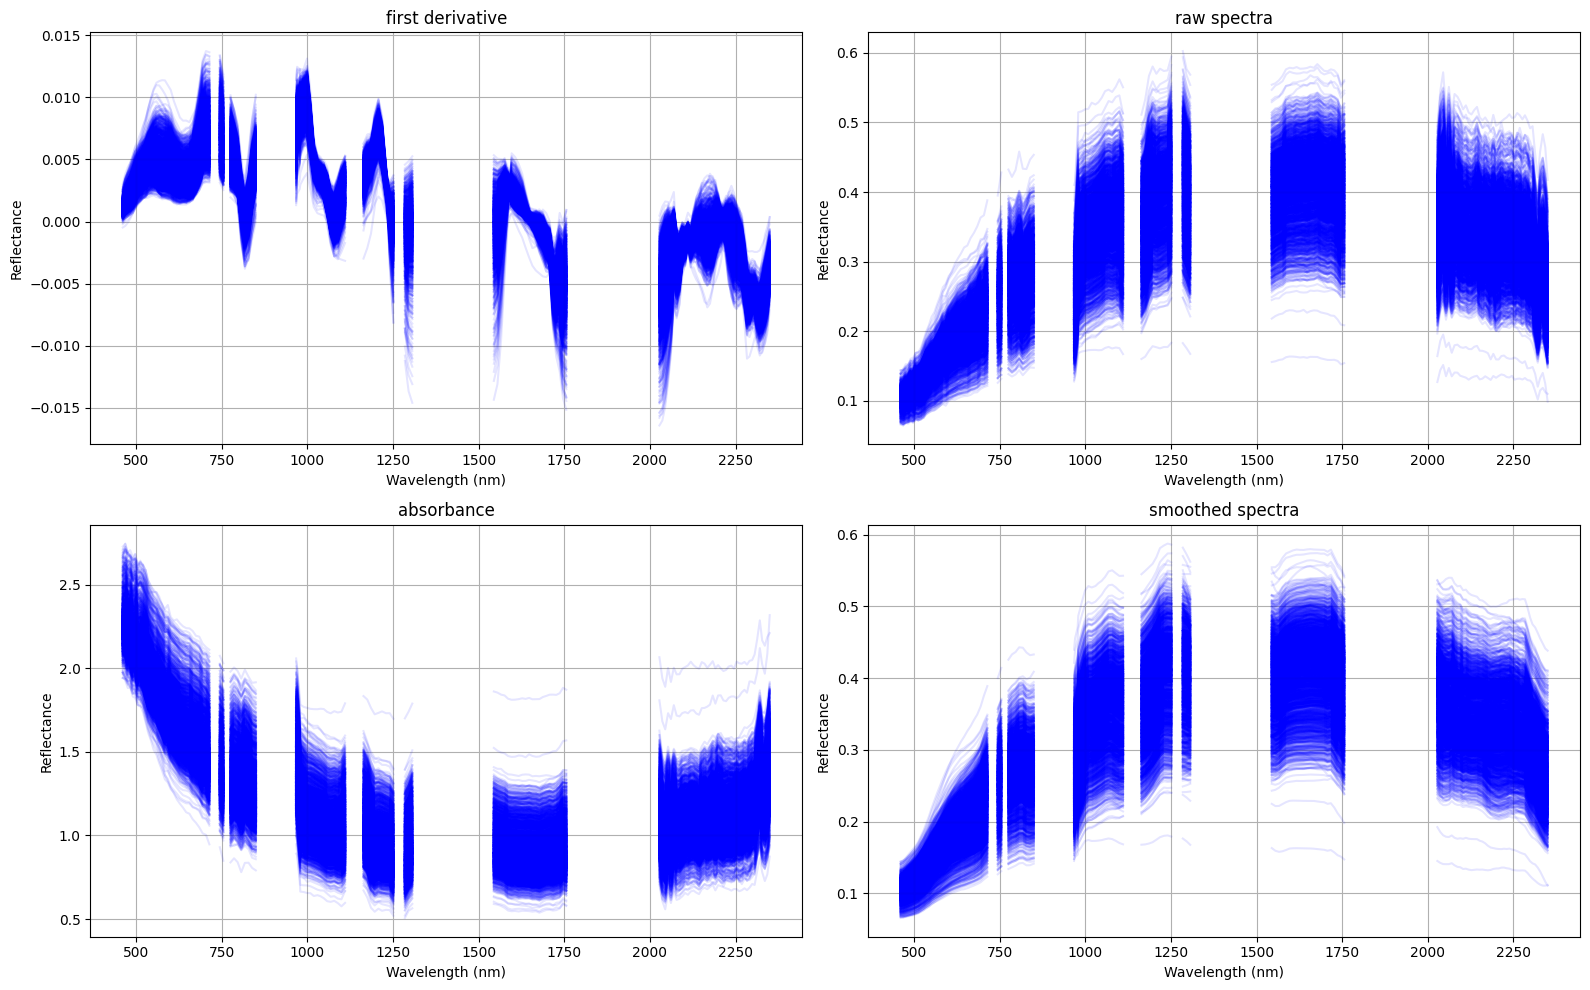

In [48]:
# Define the x-axis values (wavelengths) from the bands dictionary
x_values = bands_df[1].astype(float)

# Extract y-values (spectra only) from dataset_list
y_values_list = [data.iloc[:, 3:237] for data in dataset_list.values()]

# Extract titles from transformation names
titles = [transformation.replace('_', ' ') for transformation in dataset_list.keys()]

# Plot using your custom plotting function
plotters.plot_spectra(
    x_values,
    y_values_list,
    titles=titles,
    xlabel='Wavelength (nm)',
    ylabel='Reflectance',
    alpha=0.1,
    color='blue'
)

/home/kmisbah/CESBIO/AL_Moutmir/alMoutmir_Modeling/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/kmisbah/CESBIO/AL_Moutmir/alMoutmir_Modeling/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/kmisbah/CESBIO/AL_Moutmir/alMoutmir_Modeling/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/kmisbah/CESBIO/AL_Moutmir/alMoutmir_Modeling/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultura

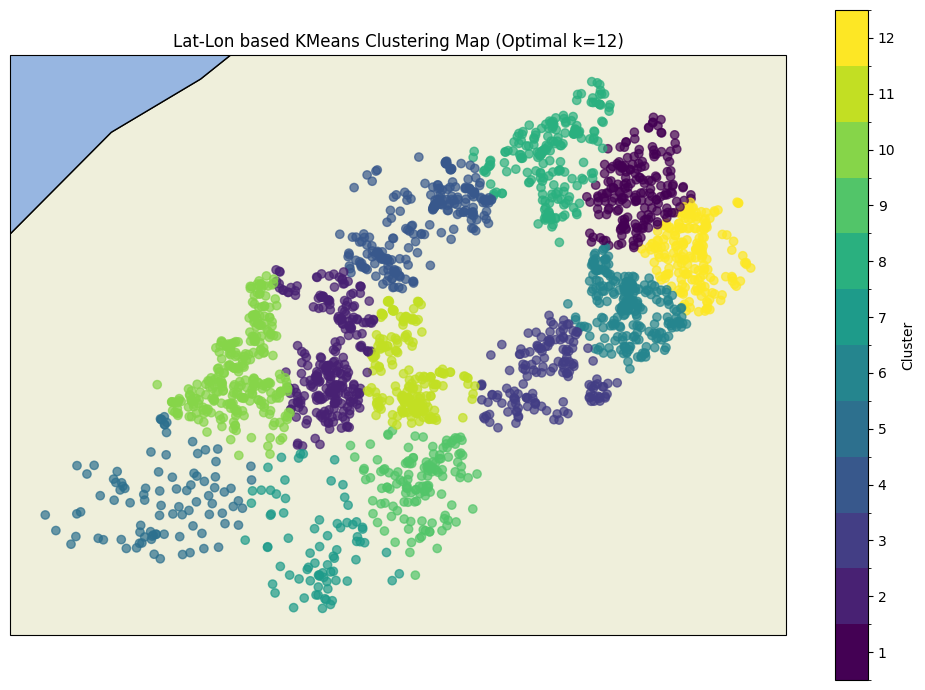

In [49]:
merged_dataset = merged_datasets[1]['raw_spectra']
helper.kmeans_clustering_map(merged_dataset, feature_cols=['Longitude_X', 'Latitude_Y'], cmap='viridis', title='Lat-Lon based KMeans Clustering Map', k_range=(12,12), show_cluster_labels=False)

In [258]:
helper.kmeans_clustering_map(merged_dataset, feature_cols=['Longitude_X', 'Latitude_Y'], cmap='viridis', title='Lat-Lon based KMeans Clustering Map', k_range=(12,12), show_map=False, return_df=True)

,Longitude_X,Latitude_Y,Sand%,Clay%,Total_Silt%,Fine silt%,Coarse silt%,Coarse element %,pH_water,CaCo3%_Total,...,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234,KMeans_Cluster
0,-8.5045,32.5532,85.0,4.0,11.0,7.0,4.0,9.0,7.34,1.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
1,-8.3182,32.7204,87.0,1.0,12.0,6.0,6.0,3.0,7.30,1.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12
2,-8.3186,32.7201,87.0,4.0,9.0,5.0,4.0,1.0,7.62,1.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12
3,-8.3359,32.6863,66.0,17.0,17.0,11.0,6.0,9.0,7.97,1.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12
4,-8.3445,32.7117,35.0,25.0,40.0,24.0,16.0,3.0,7.95,1.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2271,-8.3199,32.7213,92.0,1.0,7.0,2.0,5.0,6.0,7.43,1.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12
2272,-8.4928,32.8381,82.0,8.0,10.0,10.0,NaN,NaN,6.75,0.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
2273,-8.5384,32.7939,43.0,31.0,26.0,26.0,NaN,NaN,7.60,0.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
2274,-8.5403,32.7835,26.0,38.0,36.0,36.0,NaN,NaN,7.77,7.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8


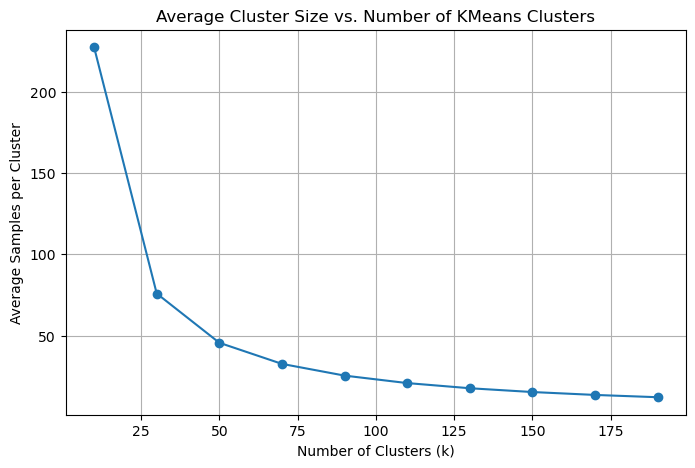

In [259]:
k_values = list(range(10, 201, 20))
avg_counts = []

for k in k_values:
    clustered_df = helper.kmeans_clustering_map(
        merged_dataset,
        feature_cols=['Longitude_X', 'Latitude_Y'],
        cmap='viridis',
        title=f'Lat-Lon based KMeans Clustering Map (k={k})',
        k_range=(k, k),
        show_map=False,
        return_df=True
    )
    cluster_counts = clustered_df['KMeans_Cluster'].value_counts()
    avg_counts.append(cluster_counts.mean())

plt.figure(figsize=(8, 5))
plt.plot(k_values, avg_counts, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Samples per Cluster')
plt.title('Average Cluster Size vs. Number of KMeans Clusters')
plt.grid(True)
plt.show()

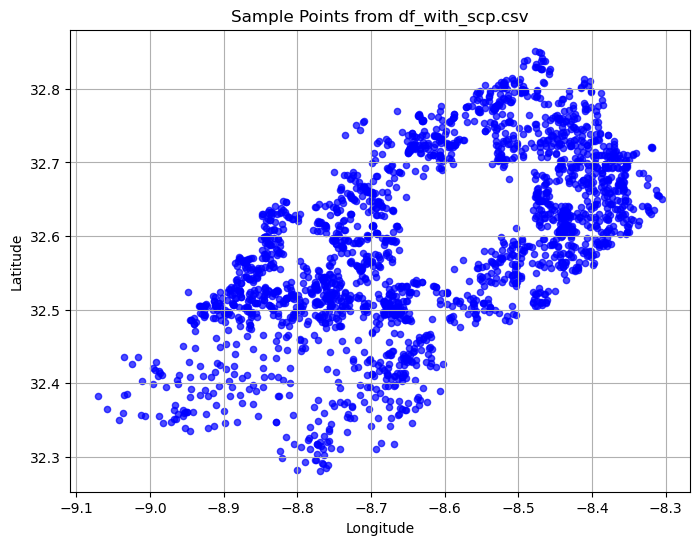

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
# Load the CSV file
df_with_scp = pd.read_csv('/Users/khalilmisbah/Desktop/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20250703_163248/doukkala_ssl_datasets/df_with_scp.csv')

# Plot points using Latitude_Y and Longitude_X
plt.figure(figsize=(8, 6))
plt.scatter(df_with_scp['Longitude_X'], df_with_scp['Latitude_Y'], s=20, color='blue', alpha=0.7)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Sample Points from df_with_scp.csv')
plt.grid(True)
plt.show()

In [42]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from pyproj import CRS

def _infer_utm_crs(lon_series, lat_series):
    lon_mean = lon_series.mean()
    lat_mean = lat_series.mean()
    zone = int((lon_mean + 180) // 6) + 1
    epsg = 32600 + zone if lat_mean >= 0 else 32700 + zone
    return CRS.from_epsg(epsg)

def regular_grid_cluster(
    df,
    cell_size_m=None,
    lon_col='Longitude_X',
    lat_col='Latitude_Y'
):
    """
    Compute grid clustering (no plotting).

    Returns
    -------
    df_out, grid_gdf[, grid_gdf_utm]
    """

    # Ensure GeoDataFrame in WGS84
    if isinstance(df, gpd.GeoDataFrame):
        gdf_wgs = df.copy()
        if gdf_wgs.crs is None:
            gdf_wgs.set_crs('EPSG:4326', inplace=True)
        elif gdf_wgs.crs.to_epsg() != 4326:
            gdf_wgs = gdf_wgs.to_crs(4326)
    else:
        gdf_wgs = gpd.GeoDataFrame(
            df.copy(),
            geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
            crs='EPSG:4326'
        )

    utm_crs = _infer_utm_crs(gdf_wgs[lon_col], gdf_wgs[lat_col])
    gdf_utm = gdf_wgs.to_crs(utm_crs)

    xmin, ymin, xmax, ymax = gdf_utm.total_bounds
    width = xmax - xmin
    height = ymax - ymin
    # Sanity check: reject suspicious cell_size_m
    if cell_size_m is None or cell_size_m <= 0:
        raise ValueError("cell_size_m must be a positive number.")

    if cell_size_m < 100:
        raise ValueError(
            f"cell_size_m={cell_size_m} m is unrealistically small. Did you pass degrees instead of meters?"
        )

    if cell_size_m > max(width, height):
        raise ValueError(
            f"cell_size_m={cell_size_m} m is larger than the dataset extent ({max(width, height):.2f} m)."
        )
    nx = max(1, int(np.ceil(width / cell_size_m)))
    ny = max(1, int(np.ceil(height / cell_size_m)))

    xs = gdf_utm.geometry.x
    ys = gdf_utm.geometry.y
    col = np.clip(((xs - xmin) / cell_size_m).astype(int), 0, nx - 1)
    row = np.clip(((ys - ymin) / cell_size_m).astype(int), 0, ny - 1)
    grid_id = (row * nx + col).astype(int)

    
    df['Grid_Col'] = col
    df['Grid_Row'] = row
    df['Grid_ID'] = grid_id
        
    occupied_cells = set(zip(row, col))

    grid_polys_utm = []
    grid_ids = []
    for r in range(ny):
        y0 = ymin + r * cell_size_m
        y1 = min(y0 + cell_size_m, ymax)
        for c in range(nx):
            if (r, c) not in occupied_cells:
                continue
            x0 = xmin + c * cell_size_m
            x1 = min(x0 + cell_size_m, xmax)
            grid_polys_utm.append(box(x0, y0, x1, y1))
            grid_ids.append(r * nx + c)

    grid_gdf_utm = gpd.GeoDataFrame({'Grid_ID': grid_ids}, geometry=grid_polys_utm, crs=utm_crs)
    grid_gdf = grid_gdf_utm.to_crs(4326)
    
    return df, grid_gdf

    

def plot_regular_grid_clusters(
    df,
    grid_gdf,
    lon_col='Longitude_X',
    lat_col='Latitude_Y',
    cmap='tab20b',
    ax=None,
    show=True,
    title=None,
    color_by='Grid_ID'
):
    """
    Plot points colored by grid (already computed) plus grid boundaries.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    sc = ax.scatter(df[lon_col], df[lat_col],
                    c=df[color_by], cmap=cmap, s=12, alpha=0.8,
                    edgecolor='none', zorder=2)
    grid_gdf.boundary.plot(ax=ax, color='lightgray', linewidth=0.5, zorder=1)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    if title is None:
        title = 'Regular Grid Clusters'
    ax.set_title(title)
    cbar = plt.colorbar(sc, ax=ax, pad=0.01)
    cbar.set_label(color_by)
    plt.tight_layout()
    if show:
        plt.show()
    return ax


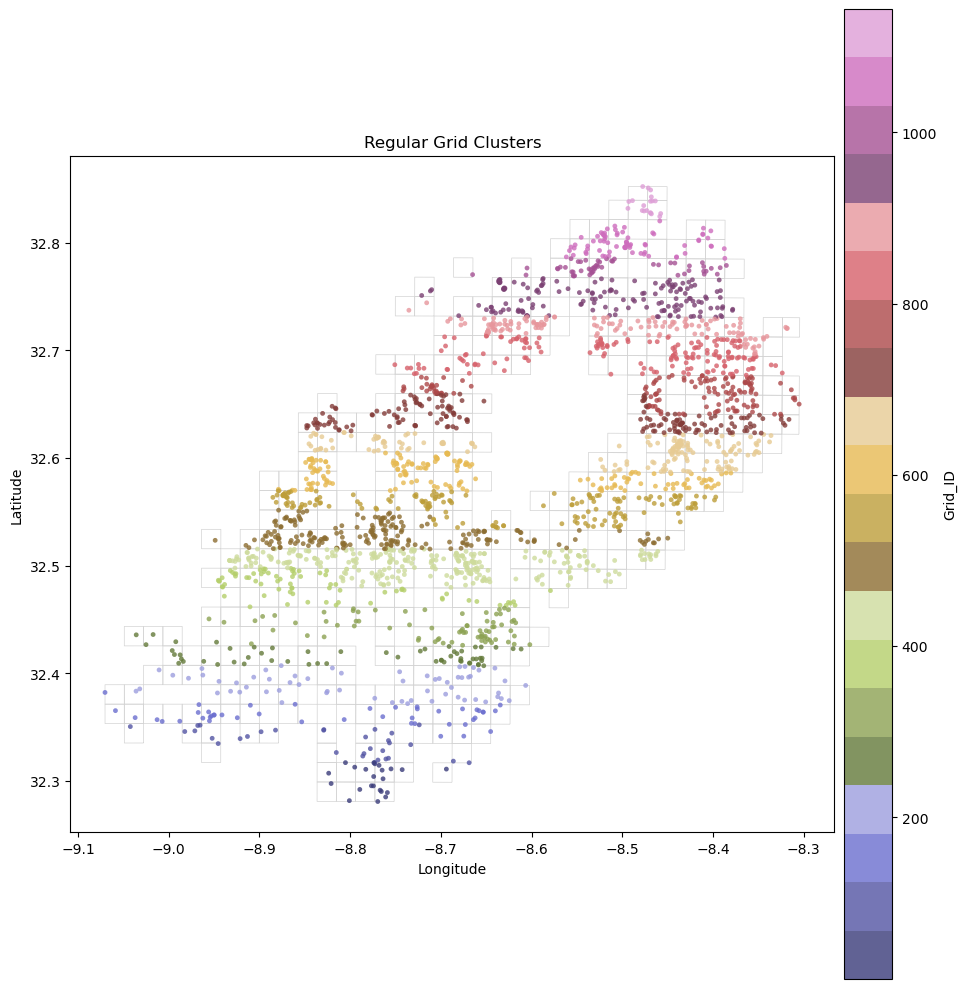

<Axes: title={'center': 'Regular Grid Clusters'}, xlabel='Longitude', ylabel='Latitude'>

In [45]:

# Example usage with meters (e.g., 5000 m cells):
df_with_scp, grid_gdf = regular_grid_cluster(df_with_scp, cell_size_m=2000)
plot_regular_grid_clusters(df_with_scp,grid_gdf)


In [24]:
from helpers.misc_utils import sanitize_names
import os
import pandas as pd

In [25]:
# Sanitize column names for all CSVs in the specified directory and overwrite them
ssl_dir = "/Users/khalilmisbah/Desktop/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20250703_163248/doukkala_ssl_datasets"

for fname in os.listdir(ssl_dir):
    if fname.lower().endswith(".csv"):
        fpath = os.path.join(ssl_dir, fname)
        try:
            df_tmp = pd.read_csv(fpath)
            original_cols = list(df_tmp.columns)
            df_tmp.columns = sanitize_names(df_tmp.columns)
            df_tmp.to_csv(fpath, index=False)
            print(f"Sanitized columns in {fname} ({len(original_cols)} columns).")
        except Exception as e:
            print(f"Failed processing {fname}: {e}")

Sanitized columns in merged_doukkala_absorbance.csv (292 columns).
Sanitized columns in merged_doukkala_raw_spectra.csv (292 columns).
Sanitized columns in merged_doukkala_smoothed_spectra.csv (292 columns).
Sanitized columns in merged_doukkala_first_derivative.csv (292 columns).
Sanitized columns in df_with_scp.csv (308 columns).


In [ ]:
from sklearn.model_selection import BaseCrossValidator
class CustomKFold(BaseCrossValidator):
    def __init__(self, n_splits=5, shuffle=False, random_state=None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X, y=None, groups=None):
        # Custom splitting logic
        pass

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

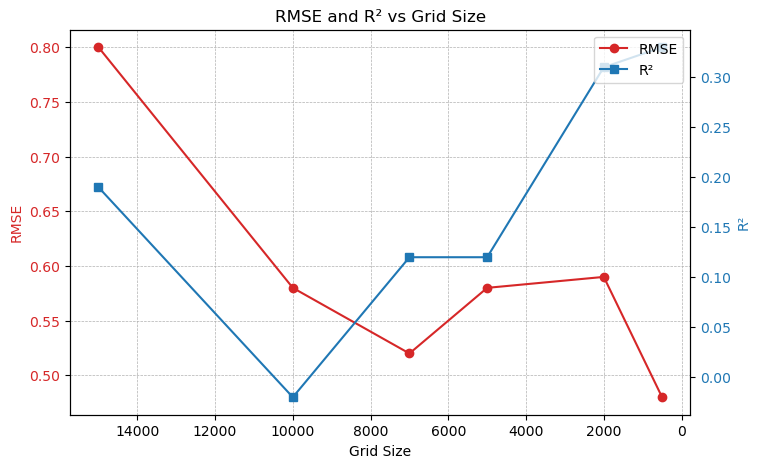

In [2]:
import matplotlib.pyplot as plt

# Data
grid_size = [15000, 10000, 7000, 5000, 2000, 500]
rmse = [0.8, 0.58, 0.52, 0.58, 0.59, 0.48]
r2 = [0.19, -0.02, 0.12, 0.12, 0.31, 0.33]

fig, ax1 = plt.subplots(figsize=(8,5))

# Plot RMSE
color = 'tab:red'
ax1.set_xlabel('Grid Size')
ax1.set_ylabel('RMSE', color=color)
ax1.plot(grid_size, rmse, marker='o', color=color, label='RMSE')
ax1.tick_params(axis='y', labelcolor=color)
#ax1.set_xscale('log')  # Makes grid sizes spaced nicely
ax1.invert_xaxis()     # Optional: largest grid size on left
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Create second y-axis for R²
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('R²', color=color)
ax2.plot(grid_size, r2, marker='s', color=color, label='R²')
ax2.tick_params(axis='y', labelcolor=color)

# Add legends
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

plt.title('RMSE and R² vs Grid Size')
plt.show()


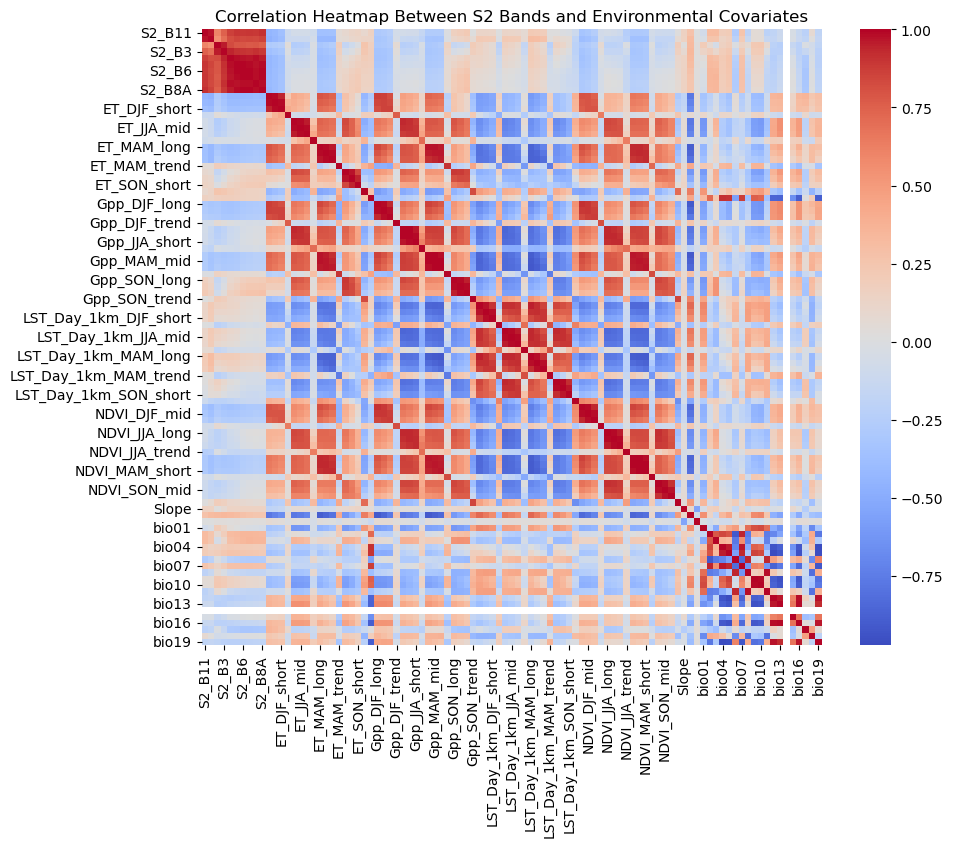

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv('/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Doukkala_soil_analysis_filtered_uuid_merged_V3_1_m.csv')

# 1. Define the specific columns you want to analyze
selected_columns = [ 'S2_B11', 'S2_B12', 'S2_B2', 'S2_B3', 'S2_B4', 'S2_B5', 'S2_B6', 'S2_B7', 'S2_B8', 'S2_B8A', 
                    'ET_DJF_long', 'ET_DJF_mid', 'ET_DJF_short', 'ET_DJF_trend', 
                    'ET_JJA_long', 'ET_JJA_mid', 'ET_JJA_short', 'ET_JJA_trend', 
                    'ET_MAM_long', 'ET_MAM_mid', 'ET_MAM_short', 'ET_MAM_trend', 
                    'ET_SON_long', 'ET_SON_mid', 'ET_SON_short', 'ET_SON_trend', 
                    'Elevation', 'Gpp_DJF_long', 'Gpp_DJF_mid', 'Gpp_DJF_short', 'Gpp_DJF_trend', 
                    'Gpp_JJA_long', 'Gpp_JJA_mid', 'Gpp_JJA_short', 'Gpp_JJA_trend', 'Gpp_MAM_long', 
                    'Gpp_MAM_mid', 'Gpp_MAM_short', 'Gpp_MAM_trend', 'Gpp_SON_long', 'Gpp_SON_mid', 
                    'Gpp_SON_short', 'Gpp_SON_trend', 'LST_Day_1km_DJF_long', 'LST_Day_1km_DJF_mid', 
                    'LST_Day_1km_DJF_short', 'LST_Day_1km_DJF_trend', 'LST_Day_1km_JJA_long', 'LST_Day_1km_JJA_mid', 
                    'LST_Day_1km_JJA_short', 'LST_Day_1km_JJA_trend', 'LST_Day_1km_MAM_long', 'LST_Day_1km_MAM_mid', 
                    'LST_Day_1km_MAM_short', 'LST_Day_1km_MAM_trend', 'LST_Day_1km_SON_long', 'LST_Day_1km_SON_mid', 
                    'LST_Day_1km_SON_short', 'LST_Day_1km_SON_trend', 'NDVI_DJF_long', 'NDVI_DJF_mid', 'NDVI_DJF_short', 
                    'NDVI_DJF_trend', 'NDVI_JJA_long', 'NDVI_JJA_mid', 'NDVI_JJA_short', 'NDVI_JJA_trend', 'NDVI_MAM_long', 
                    'NDVI_MAM_mid', 'NDVI_MAM_short', 'NDVI_MAM_trend', 'NDVI_SON_long', 'NDVI_SON_mid', 'NDVI_SON_short', 'NDVI_SON_trend','Slope','Aridity_Index','TWI','bio01','bio02','bio03','bio04','bio05','bio06','bio07','bio08','bio09','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']

# 2. Filter the dataframe to include only these columns
# (Make sure these names match exactly with your CSV headers)
subset_df = df[selected_columns]

# 3. Calculate the correlation matrix for these specific columns
corr_matrix = subset_df.corr()

# 4. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap Between S2 Bands and Environmental Covariates')
plt.show()

In [15]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import clhs as cl
roadsafe_df = pd.read_csv('/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_soil_analysis_filtered_uuid_roadsafe.csv')

In [16]:
cols = roadsafe_df.columns.tolist()
to_drop = {'lon', 'lat', 'date', 'depth_from_cm', 'depth_to_cm', 'uuid', 
           'ph_water', 'organic_matter_pct' 'exchangeable_k2o_ppm','p2o5_ehangable_olsen_ppm'
           }

# Rebuild the list, skipping the ones you don't want
filtered_cols = [c for c in cols if c not in to_drop]
filtered_cols

['sand_pct',
 'clay_pct',
 'total_silt_pct',
 'fine_silt_pct',
 'coarse_silt_pct',
 'coarse_element_pct',
 'caco3_pct_total',
 'caco3_active_pct',
 'c_e_c_meq_100g',
 'ce_ext1_5_ms_cm',
 'na2o_ppm',
 'cl_ppm',
 'na_meq_100g',
 'c_n_ratio',
 'organic_matter_pct',
 'exchangeable_k2o_ppm',
 'mgo_ppm',
 'cao_ppm',
 'iron_ppm_dtpa',
 'mn_ppm_dtpa',
 'cu_ppm_dtpa',
 'zn_ppm_dtpa',
 'b_ppm_hot_water']

In [19]:
roadsafe_df_non_null = roadsafe_df[roadsafe_df['sand_pct'].notna()].copy()

In [8]:
roadsafe_df_indexed = roadsafe_df.set_index('sand_pct')

In [22]:
# set sample number
num_sample=6000
# cLHS
sampled=cl.clhs(roadsafe_df_non_null[filtered_cols], num_sample, max_iterations=1000)
clhs_sample=roadsafe_df_non_null.iloc[sampled["sample_indices"]]
# random sample, as a comparison
random_sample=roadsafe_df_non_null.sample(num_sample)

cLHS:100%|██████████|1000/1000 [Elapsed time: 13.939240455627441, ETA: 0.0, 71.74it/s]                


In [23]:
clhs_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6000 entries, 8900 to 43536
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lon                       6000 non-null   float64
 1   lat                       6000 non-null   float64
 2   date                      6000 non-null   object 
 3   sand_pct                  6000 non-null   float64
 4   clay_pct                  5894 non-null   float64
 5   total_silt_pct            5982 non-null   float64
 6   fine_silt_pct             5981 non-null   float64
 7   coarse_silt_pct           5148 non-null   float64
 8   coarse_element_pct        3854 non-null   float64
 9   ph_water                  6000 non-null   float64
 10  caco3_pct_total           5858 non-null   float64
 11  caco3_active_pct          4965 non-null   float64
 12  c_e_c_meq_100g            5999 non-null   float64
 13  ce_ext1_5_ms_cm           6000 non-null   float64
 14  na2o_ppm 

In [24]:
clhs_sample.to_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_soil_analysis_filtered_uuid_roadsafe_6ksample.csv", index=False)

In [25]:
clhs_sample.head()

,lon,lat,date,sand_pct,clay_pct,total_silt_pct,fine_silt_pct,coarse_silt_pct,coarse_element_pct,ph_water,...,mgo_ppm,cao_ppm,iron_ppm_dtpa,mn_ppm_dtpa,cu_ppm_dtpa,zn_ppm_dtpa,b_ppm_hot_water,depth_from_cm,depth_to_cm,uuid
8900,-8.6947,32.5752,2019/08/24,78.0,12.0,10.0,6.0,4.0,12.0,7.16,...,409.0,NaN,6.1,21.3,0.3,0.2,0.9,0,30,0256937a-229b-40e1-852e-695032cbe720
3172,-7.2469,31.8616,2019/11/27,55.0,17.0,28.0,22.0,6.0,6.0,8.83,...,428.0,NaN,4.0,14.2,1.1,0.2,0.8,0,30,a8e44486-106e-41bc-9382-edbed4968953
43140,-8.1396,33.3049,2019/06/12,85.0,7.0,8.0,6.0,3.0,7.0,8.53,...,376.0,NaN,4.3,17.5,1.3,2.3,0.6,0,30,9be974cb-7bde-43cf-aab6-c2237801d645
8442,-8.4339,32.6322,2019/10/14,71.0,21.0,8.0,6.0,3.0,5.0,8.60,...,NaN,NaN,4.0,26.3,0.4,0.3,0.7,0,30,08536c8c-0b0f-41cf-9071-7eaf17692351
8582,-8.5861,32.7241,2019/08/26,75.0,11.0,14.0,7.0,7.0,8.0,7.50,...,480.0,NaN,5.6,66.1,0.4,0.7,1.0,0,30,6ae5e661-4c96-4e93-8dba-1c47806f9253


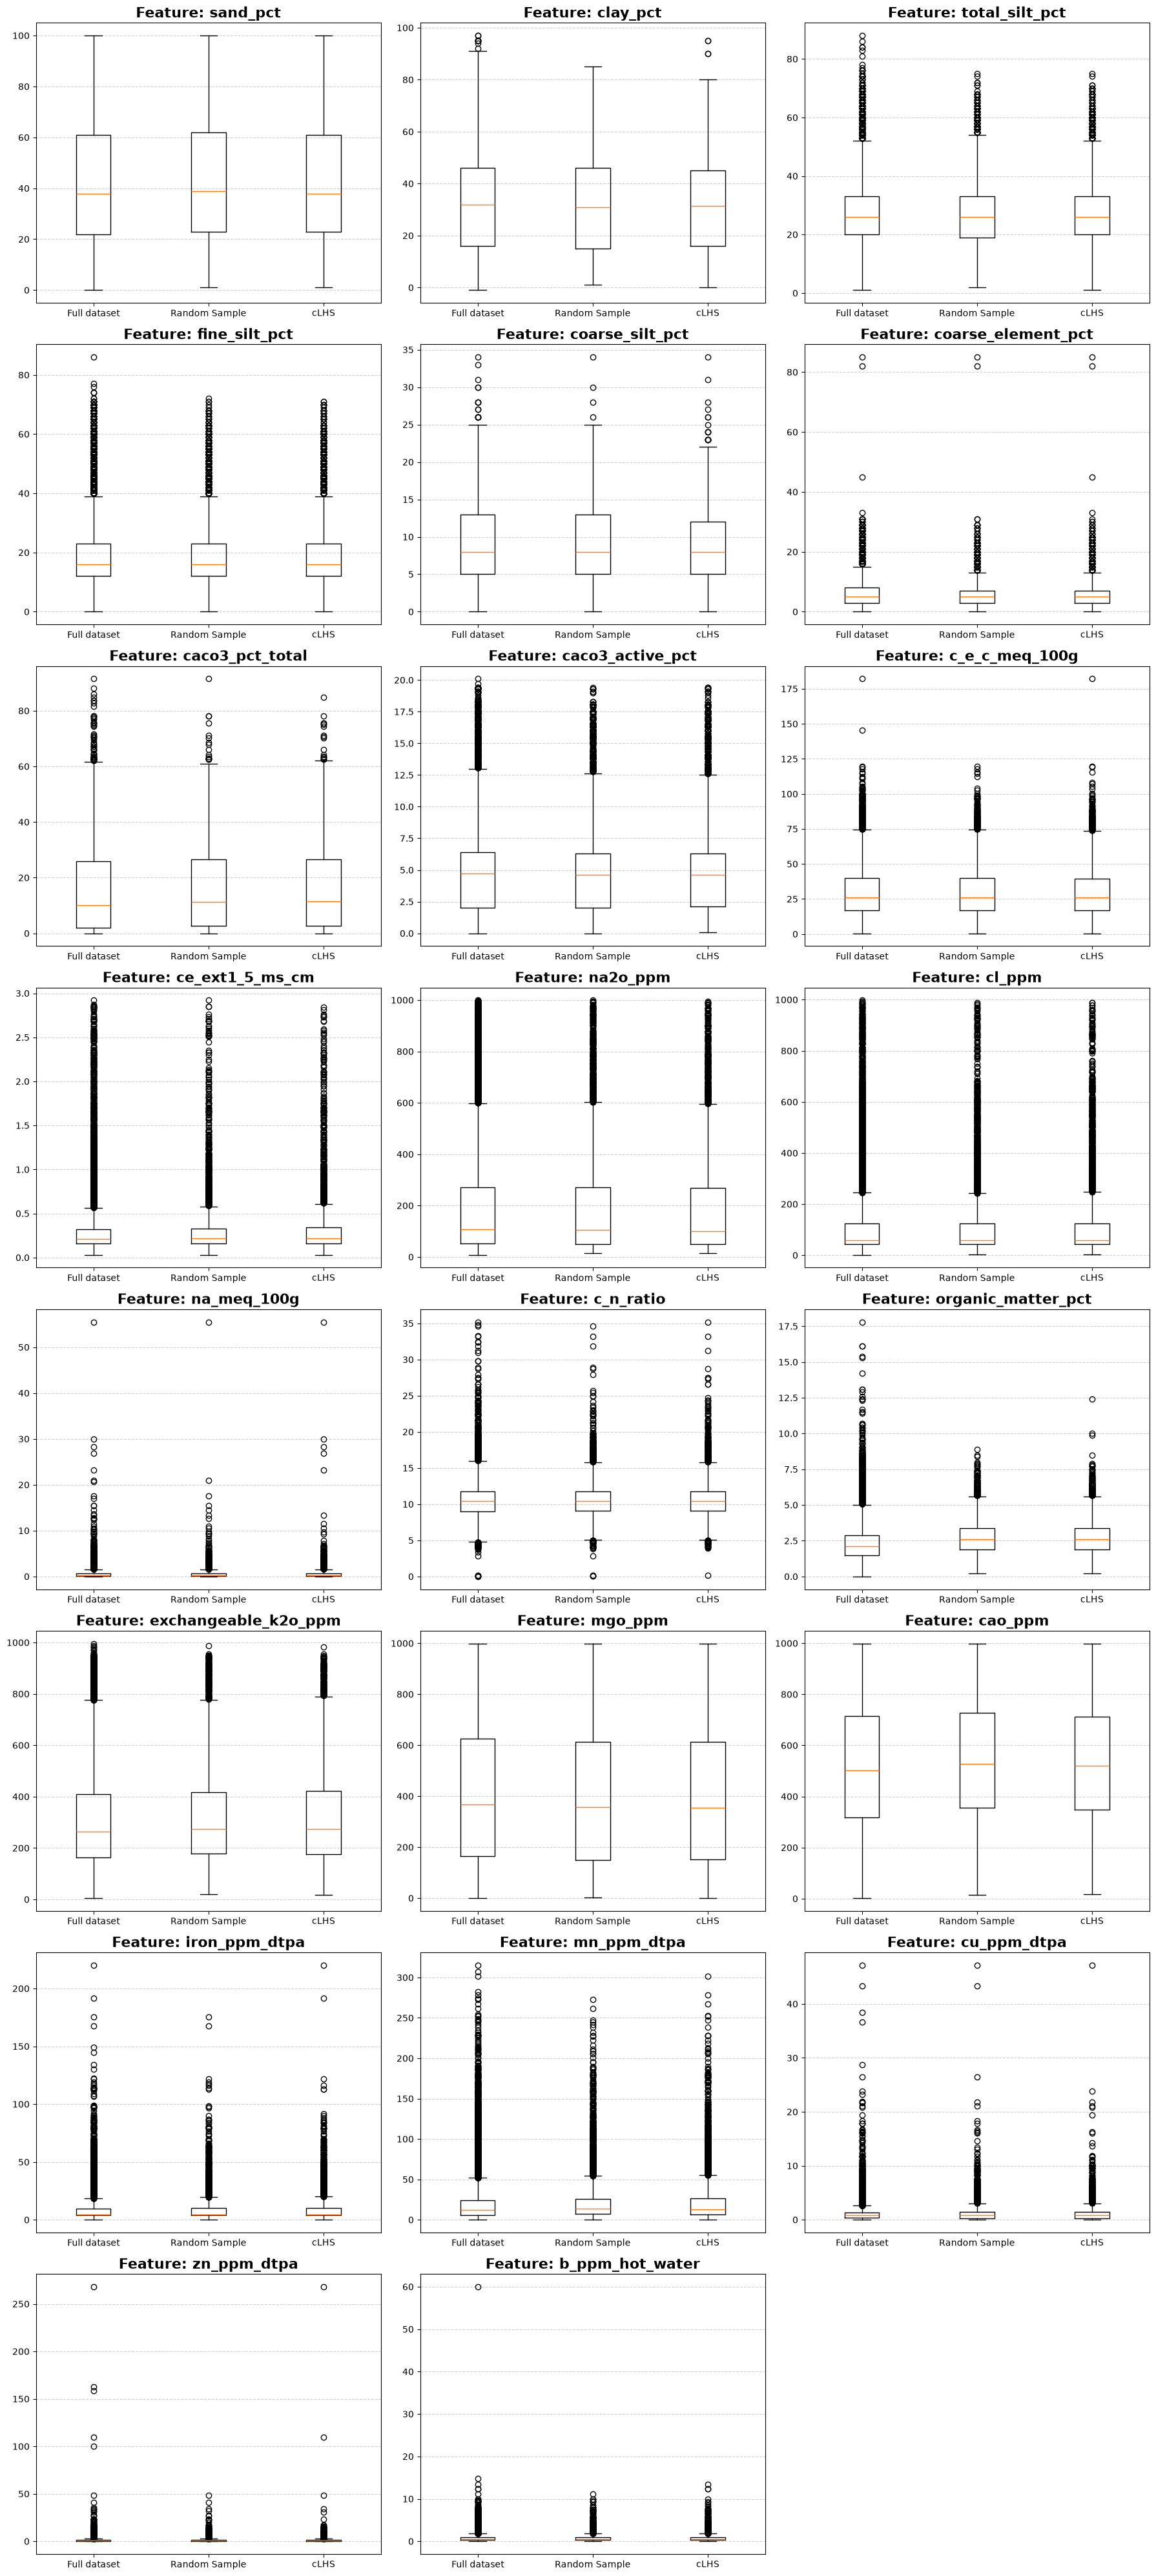

In [26]:
# --- NEW PLOTTING SECTION ---

# Calculate grid dimensions based on number of features
num_features = len(filtered_cols)
n_cols = 3  # You can change this to 2 or 4 depending on your screen width
n_rows = (num_features + n_cols - 1) // n_cols

# Create the figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten() # Flatten to iterate easily

# Global styling
matplotlib.rc('xtick', labelsize=12)
matplotlib.rc('ytick', labelsize=12)

for i, col in enumerate(filtered_cols):
    ax = axes[i]
    
    # Prepare the data for this specific feature
    # .dropna() is often good practice for boxplots to avoid errors
    data_to_plot = [
        roadsafe_df[col].dropna(),
        random_sample[col].dropna(),
        clhs_sample[col].dropna()
    ]
    
    # Create boxplot for the current feature
    ax.boxplot(data_to_plot, tick_labels=['Full dataset', 'Random Sample', 'cLHS'])
    
    # Set titles and formatting
    ax.set_title(f"Feature: {col}", fontsize=16, fontweight='bold')
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# Hide any empty subplots (if num_features isn't a multiple of n_cols)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [1]:
import glob
import os
import pandas as pd

In [4]:
VERSION = "110826"
INPUT_DIR = "/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_Soil_Predictors_2017_2025_V_" + VERSION
OUTPUT_PATH = "/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_Soil_Predictors_TS_2017_2025_V_" + VERSION + ".csv"
pattern = os.path.join(INPUT_DIR, "Morocco_Soil_Predictors_*.csv")

files = sorted(glob.glob(pattern))
if not files:
    raise FileNotFoundError(f"No files found for pattern: {pattern}")

dfs = []
for f in files:
    dfs.append(pd.read_csv(f, low_memory=False, on_bad_lines="skip"))

merged = pd.concat(dfs, ignore_index=True, sort=False)
merged.to_csv(OUTPUT_PATH, index=False)
print(f"Merged {len(files)} files -> {OUTPUT_PATH} ({len(merged)} rows, {len(merged.columns)} cols)")

Merged 9 files -> /home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_Soil_Predictors_TS_2017_2025_V_110826.csv (572347 rows, 56 cols)


In [6]:
df_roadsafe= pd.read_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_soil_analysis_filtered_uuid_roadsafe_6ksample.csv")
df_ts = pd.read_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_Soil_Predictors_TS_2017_2025_V_" + VERSION + ".csv")
df_covariates = pd.read_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_Static_Covariates_V_" + VERSION + ".csv")
df_roadsafe.info()
df_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lon                       6000 non-null   float64
 1   lat                       6000 non-null   float64
 2   date                      6000 non-null   object 
 3   sand_pct                  6000 non-null   float64
 4   clay_pct                  5894 non-null   float64
 5   total_silt_pct            5982 non-null   float64
 6   fine_silt_pct             5981 non-null   float64
 7   coarse_silt_pct           5148 non-null   float64
 8   coarse_element_pct        3854 non-null   float64
 9   ph_water                  6000 non-null   float64
 10  caco3_pct_total           5858 non-null   float64
 11  caco3_active_pct          4965 non-null   float64
 12  c_e_c_meq_100g            5999 non-null   float64
 13  ce_ext1_5_ms_cm           6000 non-null   float64
 14  na2o_ppm

In [7]:
drop_cols = ["system:index", "SU_WRB1_PH", "date", "depth_from_cm", "depth_to_cm", "exchangeable_k2o_ppm", "matched", "organic_matter_pct", "p2o5_ehangable_olsen_ppm", "ph_water", ".geo"]
df_ts = df_ts.drop(columns=drop_cols)
df_ts.head()

,Clim_water_deficit,ETa,GPP_monthly,LST_Celsius,NPP_yearly,S1_VH_asc,S1_VH_desc,S1_VV_asc,S1_VV_desc,S1_angle_asc,...,iron_ppm_dtpa,mgo_ppm,mn_ppm_dtpa,na2o_ppm,na_meq_100g,observation_date,sand_pct,total_silt_pct,uuid,zn_ppm_dtpa
0,435.0,183.0,231.00,22.209616,6194.0,-21.454326,-21.429608,-13.348033,-13.549804,36.090580,...,4.0,280.0,18.3,16.0,0.1,2017-01-01,92.0,3.0,644886a1-29aa-4cb6-855a-d712fd4a387d,0.9
1,468.0,182.0,226.50,20.808228,5603.0,-20.607536,-21.131883,-11.248180,-12.452168,40.731550,...,4.0,135.0,2.7,37.0,0.1,2017-01-01,96.0,3.0,340cea13-8b21-4f9a-a6d4-b175a7fe7d5f,0.3
2,74.0,402.0,216.25,14.309433,7409.0,-17.715127,-17.507883,-9.703134,-8.908232,38.775590,...,8.2,588.0,103.4,279.0,0.9,2017-01-01,35.0,10.0,ec448ab3-d40b-4551-bbeb-9383d96edaac,2.4
3,202.0,343.0,205.50,15.021520,3994.0,-21.481241,-22.150395,-13.686374,-13.959225,42.278324,...,4.0,219.0,13.6,17.0,0.1,2017-01-01,80.0,12.0,c9fbb360-227a-4062-80cf-b4a3bb5152c0,0.2
4,124.0,420.0,208.00,15.735887,3994.0,-22.046436,-21.271918,-14.941898,-10.685219,36.673527,...,4.8,NaN,6.3,899.0,2.9,2017-01-01,35.0,15.0,05917b66-c2e7-4c94-9a66-cb0320fbdc0e,0.3


In [8]:
#SPECIAL CASE EXPORT
df_ts['NDVI'] = (df_ts['S2_B8'] - df_ts['S2_B4']) / (df_ts['S2_B8'] + df_ts['S2_B4'])
df_ts['NBR2'] = (df_ts['S2_B11'] - df_ts['S2_B12']) / (df_ts['S2_B11'] + df_ts['S2_B12'])
df_ts['SOCI'] = df_ts['S2_B2'] / (df_ts['S2_B3'] * df_ts['S2_B4']) # Soil Organic Carbon Index
df_ts['S1_VH/VV_asc'] = df_ts['S1_VH_asc'] / df_ts['S1_VV_asc']
df_ts['S1_VH/VV_desc'] = df_ts['S1_VH_desc'] / df_ts['S1_VV_desc']
# 5. Merge with target and covariates
# df_ts_merge = df_ts.merge(df_roadsafe, on='uuid', how='left')
df_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572347 entries, 0 to 572346
Data columns (total 50 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Clim_water_deficit  508868 non-null  float64
 1   ETa                 508868 non-null  float64
 2   GPP_monthly         572347 non-null  float64
 3   LST_Celsius         572347 non-null  float64
 4   NPP_yearly          572347 non-null  float64
 5   S1_VH_asc           572347 non-null  float64
 6   S1_VH_desc          572347 non-null  float64
 7   S1_VV_asc           572347 non-null  float64
 8   S1_VV_desc          572347 non-null  float64
 9   S1_angle_asc        572347 non-null  float64
 10  S1_angle_desc       572347 non-null  float64
 11  S2_B11              572347 non-null  float64
 12  S2_B12              572347 non-null  float64
 13  S2_B2               572347 non-null  float64
 14  S2_B3               572347 non-null  float64
 15  S2_B4               572347 non-nul

In [9]:
df_covariates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5339 entries, 0 to 5338
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   system:index        5339 non-null   object 
 1   Landform_Class      5339 non-null   int64  
 2   S2_B11_barest       5339 non-null   float64
 3   S2_B11_barest_sd    5339 non-null   float64
 4   S2_B12_barest       5339 non-null   float64
 5   S2_B12_barest_sd    5339 non-null   float64
 6   S2_B2_barest        5339 non-null   float64
 7   S2_B2_barest_sd     5339 non-null   float64
 8   S2_B3_barest        5339 non-null   float64
 9   S2_B3_barest_sd     5339 non-null   float64
 10  S2_B4_barest        5339 non-null   float64
 11  S2_B4_barest_sd     5339 non-null   float64
 12  S2_B5_barest        5339 non-null   float64
 13  S2_B5_barest_sd     5339 non-null   float64
 14  S2_B6_barest        5339 non-null   float64
 15  S2_B6_barest_sd     5339 non-null   float64
 16  S2_B7_

In [10]:
# Add prefixes to df_ts_merge column names
prefix_mapping = {
    'NDVI': 'AG_NDVI',
    'NPP_yearly': 'AG_NPP_yearly',
    'GPP_monthly': 'AG_GPP_monthly',
    'SOCI': 'SOIL_SOCI',
    'NBR2': 'SOIL_NBR2',
    'SM': 'SOIL_SM',
    'Clim_water_deficit': 'CLIM_Clim_water_deficit',
    'ETa': 'CLIM_ETa',
    'LST_Celsius': 'CLIM_LST_Celsius'
}

df_ts = df_ts.rename(columns=prefix_mapping)
df_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572347 entries, 0 to 572346
Data columns (total 50 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   CLIM_Clim_water_deficit  508868 non-null  float64
 1   CLIM_ETa                 508868 non-null  float64
 2   AG_GPP_monthly           572347 non-null  float64
 3   CLIM_LST_Celsius         572347 non-null  float64
 4   AG_NPP_yearly            572347 non-null  float64
 5   S1_VH_asc                572347 non-null  float64
 6   S1_VH_desc               572347 non-null  float64
 7   S1_VV_asc                572347 non-null  float64
 8   S1_VV_desc               572347 non-null  float64
 9   S1_angle_asc             572347 non-null  float64
 10  S1_angle_desc            572347 non-null  float64
 11  S2_B11                   572347 non-null  float64
 12  S2_B12                   572347 non-null  float64
 13  S2_B2                    572347 non-null  float64
 14  S2_B

In [11]:
df_covariates.columns = df_covariates.columns.str.lower()
cov_cols_drop = [".geo", "system:index"]
df_covariates = df_covariates.drop(columns=cov_cols_drop)
df_covariates["elevation"] = df_covariates["elevation"].clip(lower=0)
df_covariates.head()

,landform_class,s2_b11_barest,s2_b11_barest_sd,s2_b12_barest,s2_b12_barest_sd,s2_b2_barest,s2_b2_barest_sd,s2_b3_barest,s2_b3_barest_sd,s2_b4_barest,...,bd_median_0_30cm,clay_median_0_30cm,elevation,ph_median_0_30cm,sand_median_0_30cm,slope,soc_median_0_30cm,swc_median_0_30cm,texture_20cm,uuid
0,31,0.414983,0.055325,0.382246,0.050267,0.086769,0.024427,0.128150,0.028406,0.198415,...,157.0,28.0,24,81.0,40.0,7,2.0,20.0,4,644886a1-29aa-4cb6-855a-d712fd4a387d
1,31,0.381300,0.038700,0.331060,0.032847,0.093000,0.019490,0.130900,0.024389,0.189950,...,161.0,31.0,61,80.0,35.0,2,2.0,28.0,4,340cea13-8b21-4f9a-a6d4-b175a7fe7d5f
2,21,0.344100,0.060102,0.296600,0.047685,0.108500,0.021129,0.144400,0.025826,0.178200,...,163.0,29.0,7,70.0,38.0,1,2.0,25.0,4,ec448ab3-d40b-4551-bbeb-9383d96edaac
3,21,0.404398,0.044080,0.358550,0.037164,0.091625,0.020921,0.129800,0.026495,0.190960,...,156.0,37.0,416,78.0,33.0,5,2.0,27.0,4,c9fbb360-227a-4062-80cf-b4a3bb5152c0
4,31,0.251400,0.059293,0.220129,0.046969,0.053400,0.024660,0.078433,0.031628,0.122750,...,149.0,37.0,414,75.0,30.0,3,3.0,28.0,4,05917b66-c2e7-4c94-9a66-cb0320fbdc0e


In [12]:
import re
from pathlib import Path

predictors_dir = Path("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_Soil_Predictors_2017_2025")
landform_files = glob.glob(str(predictors_dir / "*landform*class*.csv"))

if not landform_files:
    raise FileNotFoundError(f"No landform classes CSV found in: {predictors_dir}")

landform_classes = pd.read_csv(landform_files[0])
landform_classes.columns = landform_classes.columns.str.strip()

if not {"Value", "Description"}.issubset(landform_classes.columns):
    raise ValueError("The landform classes CSV must contain 'Value' and 'Description' columns.")

def clean_text(s):
    s = str(s).strip().lower()
    s = re.sub(r"[^a-z0-9]+", "_", s)
    return s.strip("_")

landform_map = (
    landform_classes
    .assign(Description_clean=landform_classes["Description"].map(clean_text))
    .set_index("Value")["Description_clean"]
    .to_dict()
)

df_covariates["landform_class"] = df_covariates["landform_class"].map(landform_map).fillna(df_covariates["landform_class"])

df_covariates.head()

,landform_class,s2_b11_barest,s2_b11_barest_sd,s2_b12_barest,s2_b12_barest_sd,s2_b2_barest,s2_b2_barest_sd,s2_b3_barest,s2_b3_barest_sd,s2_b4_barest,...,bd_median_0_30cm,clay_median_0_30cm,elevation,ph_median_0_30cm,sand_median_0_30cm,slope,soc_median_0_30cm,swc_median_0_30cm,texture_20cm,uuid
0,lower_slope_warm,0.414983,0.055325,0.382246,0.050267,0.086769,0.024427,0.128150,0.028406,0.198415,...,157.0,28.0,24,81.0,40.0,7,2.0,20.0,4,644886a1-29aa-4cb6-855a-d712fd4a387d
1,lower_slope_warm,0.381300,0.038700,0.331060,0.032847,0.093000,0.019490,0.130900,0.024389,0.189950,...,161.0,31.0,61,80.0,35.0,2,2.0,28.0,4,340cea13-8b21-4f9a-a6d4-b175a7fe7d5f
2,upper_slope_warm,0.344100,0.060102,0.296600,0.047685,0.108500,0.021129,0.144400,0.025826,0.178200,...,163.0,29.0,7,70.0,38.0,1,2.0,25.0,4,ec448ab3-d40b-4551-bbeb-9383d96edaac
3,upper_slope_warm,0.404398,0.044080,0.358550,0.037164,0.091625,0.020921,0.129800,0.026495,0.190960,...,156.0,37.0,416,78.0,33.0,5,2.0,27.0,4,c9fbb360-227a-4062-80cf-b4a3bb5152c0
4,lower_slope_warm,0.251400,0.059293,0.220129,0.046969,0.053400,0.024660,0.078433,0.031628,0.122750,...,149.0,37.0,414,75.0,30.0,3,3.0,28.0,4,05917b66-c2e7-4c94-9a66-cb0320fbdc0e


In [13]:
predictors_dir = Path("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_Soil_Predictors_2017_2025")
texture_files = glob.glob(str(predictors_dir / "*texture*class*.csv"))

if not texture_files:
    raise FileNotFoundError(f"No texture classes CSV found in: {predictors_dir}")

texture_classes = pd.read_csv(texture_files[0])
texture_classes.columns = texture_classes.columns.str.strip()

if not {"Value", "Description"}.issubset(texture_classes.columns):
    raise ValueError("The texture classes CSV must contain 'Value' and 'Description' columns.")

def clean_text(s):
    s = str(s).strip().lower()
    s = re.sub(r"[^a-z0-9]+", "_", s)
    return s.strip("_")

texture_map = (
    texture_classes
    .assign(Description_clean=texture_classes["Description"].map(clean_text))
    .set_index("Value")["Description_clean"]
    .to_dict()
)

df_covariates["texture_20cm"] = df_covariates["texture_20cm"].map(texture_map).fillna(df_covariates["texture_20cm"])

df_covariates.head()

,landform_class,s2_b11_barest,s2_b11_barest_sd,s2_b12_barest,s2_b12_barest_sd,s2_b2_barest,s2_b2_barest_sd,s2_b3_barest,s2_b3_barest_sd,s2_b4_barest,...,bd_median_0_30cm,clay_median_0_30cm,elevation,ph_median_0_30cm,sand_median_0_30cm,slope,soc_median_0_30cm,swc_median_0_30cm,texture_20cm,uuid
0,lower_slope_warm,0.414983,0.055325,0.382246,0.050267,0.086769,0.024427,0.128150,0.028406,0.198415,...,157.0,28.0,24,81.0,40.0,7,2.0,20.0,cllo,644886a1-29aa-4cb6-855a-d712fd4a387d
1,lower_slope_warm,0.381300,0.038700,0.331060,0.032847,0.093000,0.019490,0.130900,0.024389,0.189950,...,161.0,31.0,61,80.0,35.0,2,2.0,28.0,cllo,340cea13-8b21-4f9a-a6d4-b175a7fe7d5f
2,upper_slope_warm,0.344100,0.060102,0.296600,0.047685,0.108500,0.021129,0.144400,0.025826,0.178200,...,163.0,29.0,7,70.0,38.0,1,2.0,25.0,cllo,ec448ab3-d40b-4551-bbeb-9383d96edaac
3,upper_slope_warm,0.404398,0.044080,0.358550,0.037164,0.091625,0.020921,0.129800,0.026495,0.190960,...,156.0,37.0,416,78.0,33.0,5,2.0,27.0,cllo,c9fbb360-227a-4062-80cf-b4a3bb5152c0
4,lower_slope_warm,0.251400,0.059293,0.220129,0.046969,0.053400,0.024660,0.078433,0.031628,0.122750,...,149.0,37.0,414,75.0,30.0,3,3.0,28.0,cllo,05917b66-c2e7-4c94-9a66-cb0320fbdc0e


In [14]:
# Keep only uuid-year groups with more than 10 records
df_ts_work = df_ts.copy()

# Parse date and extract year
df_ts_work["observation_date"] = pd.to_datetime(df_ts_work["observation_date"], errors="coerce")
df_ts_work["year"] = df_ts_work["observation_date"].dt.year

before_rows = len(df_ts_work)

# Count rows per (uuid, year), then filter
counts_per_uuid_year = df_ts_work.groupby(["uuid", "year"])["uuid"].transform("size")
df_ts_filtered = df_ts_work[(df_ts_work["year"].notna()) & (counts_per_uuid_year > 20)].copy()

after_rows = len(df_ts_filtered)

print(f"Rows before filtering: {before_rows}")
print(f"Rows after filtering : {after_rows}")
print(f"Rows removed         : {before_rows - after_rows}")

Rows before filtering: 572347
Rows after filtering : 0
Rows removed         : 572347


In [19]:
df_roadsafe["organic_matter_g_kg"] = df_roadsafe["organic_matter_pct"] * 10
df_roadsafe = df_roadsafe.drop(columns=["date", "depth_from_cm", "depth_to_cm", "cao_ppm", "organic_matter_pct"], errors="ignore")
df_roadsafe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lon                       6000 non-null   float64
 1   lat                       6000 non-null   float64
 2   sand_pct                  6000 non-null   float64
 3   clay_pct                  5894 non-null   float64
 4   total_silt_pct            5982 non-null   float64
 5   fine_silt_pct             5981 non-null   float64
 6   coarse_silt_pct           5148 non-null   float64
 7   coarse_element_pct        3854 non-null   float64
 8   ph_water                  6000 non-null   float64
 9   caco3_pct_total           5858 non-null   float64
 10  caco3_active_pct          4965 non-null   float64
 11  c_e_c_meq_100g            5999 non-null   float64
 12  ce_ext1_5_ms_cm           6000 non-null   float64
 13  na2o_ppm                  4975 non-null   float64
 14  cl_ppm  

In [ ]:
df_ts.to_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_Soil_Predictors_2017_2025_TS_with_indices_V_" + VERSION + ".csv", index=False)
df_covariates.to_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_Static_Covariates_Processed_V_" + VERSION + ".csv", index=False)
df_roadsafe.to_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_soil_targets_uuid_roadsafe_6ksample_V_" + VERSION + ".csv", index=False)

In [17]:
import numpy as np
import pandas as pd

# 1. Define the specific quantile levels requested
# q10, q25, q50, q75, q90
quantile_levels = [0.1, 0.25, 0.5, 0.75, 0.9]

uuid_to_ph = df_ts[['uuid']].drop_duplicates('uuid')
prefixes = ("S1_", "S2_", "AG_", "SOIL_", "CLIM_")
band_cols = [c for c in df_ts.columns if c.startswith(prefixes)]
# 2. Compute the quantiles
uuid_band_quantiles = (
    df_ts
    .groupby("uuid")[band_cols]
    .quantile(quantile_levels)
    .unstack(level=1)
)

# 3. Flatten MultiIndex columns: (B11, 0.25) -> B11_q25
uuid_band_quantiles.columns = [
    f"{band}_q{int(q * 100):02d}" for band, q in uuid_band_quantiles.columns
]

# 4. Compute IQR (q75 - q25) for each band
for band in band_cols:
    q75_col = f"{band}_q75"
    q25_col = f"{band}_q25"
    iqr_col = f"{band}_iqr"
    uuid_band_quantiles[iqr_col] = uuid_band_quantiles[q75_col] - uuid_band_quantiles[q25_col]

uuid_band_quantiles = uuid_band_quantiles.reset_index()

print(f"New shape with IQR columns: {uuid_band_quantiles.shape}")

# 5. Merge with target and covariates
uuid_band_quantiles = uuid_band_quantiles.merge(uuid_to_ph, on='uuid', how='left').merge(df_covariates, on='uuid', how='left')

uuid_band_quantiles.head()


New shape with IQR columns: (5761, 169)


,uuid,CLIM_Clim_water_deficit_q10,CLIM_Clim_water_deficit_q25,CLIM_Clim_water_deficit_q50,CLIM_Clim_water_deficit_q75,CLIM_Clim_water_deficit_q90,CLIM_ETa_q10,CLIM_ETa_q25,CLIM_ETa_q50,CLIM_ETa_q75,...,aspect,bd_median_0_30cm,clay_median_0_30cm,elevation,ph_median_0_30cm,sand_median_0_30cm,slope,soc_median_0_30cm,swc_median_0_30cm,texture_20cm
0,000b0783-280c-4ec6-8b28-73dc5a260b6c,268.6,714.75,1181.5,1664.25,1845.6,3.0,10.5,39.5,184.00,...,293.0,158.0,30.0,171.0,82.0,37.0,2.0,3.0,25.0,cllo
1,000f0ae8-578d-4a41-87fc-b2e8d3677b9a,0.0,163.00,885.0,1593.00,1914.2,13.2,47.0,182.0,488.00,...,0.0,153.0,24.0,299.0,76.0,42.0,0.0,3.0,20.0,lo
2,0016b60d-a6a1-4270-82d7-1f08e8314497,0.0,195.50,850.5,1831.50,2287.0,45.0,75.5,207.5,573.75,...,117.0,150.0,26.0,880.0,76.0,36.0,6.0,2.0,21.0,lo
3,00208147-e0ff-4f5f-b933-e95c954ef705,74.2,337.00,993.0,1950.00,2392.4,18.0,39.0,164.0,489.00,...,230.0,152.0,25.0,442.0,76.0,36.0,1.0,2.0,23.0,lo
4,0029c48e-94b6-4264-8e43-0c9dffc9bb92,92.2,477.50,992.0,1733.50,2137.2,28.6,49.5,152.0,310.00,...,255.0,149.0,27.0,1049.0,75.0,39.0,3.0,2.0,23.0,lo


In [18]:
uuid_band_quantiles.describe(include='all')

,uuid,CLIM_Clim_water_deficit_q10,CLIM_Clim_water_deficit_q25,CLIM_Clim_water_deficit_q50,CLIM_Clim_water_deficit_q75,CLIM_Clim_water_deficit_q90,CLIM_ETa_q10,CLIM_ETa_q25,CLIM_ETa_q50,CLIM_ETa_q75,...,aspect,bd_median_0_30cm,clay_median_0_30cm,elevation,ph_median_0_30cm,sand_median_0_30cm,slope,soc_median_0_30cm,swc_median_0_30cm,texture_20cm
count,5761,5761.000000,5761.000000,5761.000000,5761.000000,5761.000000,5761.000000,5761.000000,5761.000000,5761.000000,...,5338.000000,5338.000000,5338.000000,5338.000000,5338.000000,5338.000000,5338.000000,5338.000000,5338.000000,5338
unique,5761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,ffe81454-ba88-4bbc-bb08-9dd246815aee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lo
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2693
mean,NaN,116.804131,377.476914,974.406179,1744.062836,2111.564364,23.937146,53.706778,168.282243,394.667940,...,161.769577,154.562945,27.575871,510.577370,76.481266,38.924316,4.542151,1.978082,22.697640,NaN
std,NaN,158.576044,197.627385,205.603319,188.081539,234.659537,18.056103,35.274041,90.961936,141.607501,...,111.037873,7.448220,4.418389,434.357766,3.160459,5.859792,5.520653,0.834028,4.669556,NaN
min,NaN,0.000000,0.000000,454.000000,1267.000000,1393.800000,0.000000,2.000000,9.000000,25.750000,...,0.000000,119.000000,10.000000,0.000000,63.000000,16.000000,0.000000,0.000000,2.000000,NaN
25%,NaN,0.000000,211.000000,857.500000,1615.750000,1947.200000,10.000000,25.750000,91.000000,262.000000,...,59.250000,151.000000,25.000000,183.000000,74.000000,35.000000,1.000000,2.000000,21.000000,NaN
50%,NaN,42.200000,371.000000,979.000000,1711.000000,2104.400000,19.000000,48.000000,160.000000,436.000000,...,166.000000,155.000000,27.000000,423.000000,76.500000,38.000000,3.000000,2.000000,23.000000,NaN
75%,NaN,211.400000,532.000000,1097.500000,1862.750000,2276.000000,32.200000,72.000000,214.000000,512.000000,...,270.000000,159.000000,30.000000,693.000000,79.000000,42.000000,5.000000,2.000000,26.000000,NaN


In [21]:
# Keep one record per uuid in soil table, then join all soil features into time series table
roadsafe_by_uuid = df_roadsafe.drop_duplicates(subset="uuid")

uuid_band_quantiles = uuid_band_quantiles.merge(
    roadsafe_by_uuid,
    on="uuid",
    how="left"
)
print(uuid_band_quantiles.shape)
uuid_band_quantiles.head()

(5761, 228)


,uuid,CLIM_Clim_water_deficit_q10,CLIM_Clim_water_deficit_q25,CLIM_Clim_water_deficit_q50,CLIM_Clim_water_deficit_q75,CLIM_Clim_water_deficit_q90,CLIM_ETa_q10,CLIM_ETa_q25,CLIM_ETa_q50,CLIM_ETa_q75,...,c_n_ratio,exchangeable_k2o_ppm,p2o5_ehangable_olsen_ppm,mgo_ppm,iron_ppm_dtpa,mn_ppm_dtpa,cu_ppm_dtpa,zn_ppm_dtpa,b_ppm_hot_water,organic_matter_g_kg
0,000b0783-280c-4ec6-8b28-73dc5a260b6c,268.6,714.75,1181.5,1664.25,1845.6,3.0,10.5,39.5,184.00,...,8.2,240.0,189.0,504.0,4.0,5.3,0.4,0.7,0.5,15.0
1,000f0ae8-578d-4a41-87fc-b2e8d3677b9a,0.0,163.00,885.0,1593.00,1914.2,13.2,47.0,182.0,488.00,...,11.7,180.0,47.0,51.0,4.0,12.6,0.5,0.9,1.2,12.0
2,0016b60d-a6a1-4270-82d7-1f08e8314497,0.0,195.50,850.5,1831.50,2287.0,45.0,75.5,207.5,573.75,...,10.2,763.0,175.0,589.0,21.2,27.6,1.9,6.9,0.4,25.0
3,00208147-e0ff-4f5f-b933-e95c954ef705,74.2,337.00,993.0,1950.00,2392.4,18.0,39.0,164.0,489.00,...,10.6,250.0,32.0,NaN,8.8,6.2,0.9,0.9,0.2,29.0
4,0029c48e-94b6-4264-8e43-0c9dffc9bb92,92.2,477.50,992.0,1733.50,2137.2,28.6,49.5,152.0,310.00,...,8.1,718.0,202.0,104.0,12.5,77.8,NaN,6.9,NaN,35.0


In [22]:
uuid_band_quantiles.head()

,uuid,CLIM_Clim_water_deficit_q10,CLIM_Clim_water_deficit_q25,CLIM_Clim_water_deficit_q50,CLIM_Clim_water_deficit_q75,CLIM_Clim_water_deficit_q90,CLIM_ETa_q10,CLIM_ETa_q25,CLIM_ETa_q50,CLIM_ETa_q75,...,c_n_ratio,exchangeable_k2o_ppm,p2o5_ehangable_olsen_ppm,mgo_ppm,iron_ppm_dtpa,mn_ppm_dtpa,cu_ppm_dtpa,zn_ppm_dtpa,b_ppm_hot_water,organic_matter_g_kg
0,000b0783-280c-4ec6-8b28-73dc5a260b6c,268.6,714.75,1181.5,1664.25,1845.6,3.0,10.5,39.5,184.00,...,8.2,240.0,189.0,504.0,4.0,5.3,0.4,0.7,0.5,15.0
1,000f0ae8-578d-4a41-87fc-b2e8d3677b9a,0.0,163.00,885.0,1593.00,1914.2,13.2,47.0,182.0,488.00,...,11.7,180.0,47.0,51.0,4.0,12.6,0.5,0.9,1.2,12.0
2,0016b60d-a6a1-4270-82d7-1f08e8314497,0.0,195.50,850.5,1831.50,2287.0,45.0,75.5,207.5,573.75,...,10.2,763.0,175.0,589.0,21.2,27.6,1.9,6.9,0.4,25.0
3,00208147-e0ff-4f5f-b933-e95c954ef705,74.2,337.00,993.0,1950.00,2392.4,18.0,39.0,164.0,489.00,...,10.6,250.0,32.0,NaN,8.8,6.2,0.9,0.9,0.2,29.0
4,0029c48e-94b6-4264-8e43-0c9dffc9bb92,92.2,477.50,992.0,1733.50,2137.2,28.6,49.5,152.0,310.00,...,8.1,718.0,202.0,104.0,12.5,77.8,NaN,6.9,NaN,35.0


In [27]:
uuid_band_quantiles.columns.tolist()

['uuid',
 'CLIM_Clim_water_deficit_q10',
 'CLIM_Clim_water_deficit_q25',
 'CLIM_Clim_water_deficit_q50',
 'CLIM_Clim_water_deficit_q75',
 'CLIM_Clim_water_deficit_q90',
 'CLIM_ETa_q10',
 'CLIM_ETa_q25',
 'CLIM_ETa_q50',
 'CLIM_ETa_q75',
 'CLIM_ETa_q90',
 'AG_GPP_monthly_q10',
 'AG_GPP_monthly_q25',
 'AG_GPP_monthly_q50',
 'AG_GPP_monthly_q75',
 'AG_GPP_monthly_q90',
 'CLIM_LST_Celsius_q10',
 'CLIM_LST_Celsius_q25',
 'CLIM_LST_Celsius_q50',
 'CLIM_LST_Celsius_q75',
 'CLIM_LST_Celsius_q90',
 'AG_NPP_yearly_q10',
 'AG_NPP_yearly_q25',
 'AG_NPP_yearly_q50',
 'AG_NPP_yearly_q75',
 'AG_NPP_yearly_q90',
 'S1_VH_asc_q10',
 'S1_VH_asc_q25',
 'S1_VH_asc_q50',
 'S1_VH_asc_q75',
 'S1_VH_asc_q90',
 'S1_VH_desc_q10',
 'S1_VH_desc_q25',
 'S1_VH_desc_q50',
 'S1_VH_desc_q75',
 'S1_VH_desc_q90',
 'S1_VV_asc_q10',
 'S1_VV_asc_q25',
 'S1_VV_asc_q50',
 'S1_VV_asc_q75',
 'S1_VV_asc_q90',
 'S1_VV_desc_q10',
 'S1_VV_desc_q25',
 'S1_VV_desc_q50',
 'S1_VV_desc_q75',
 'S1_VV_desc_q90',
 'S1_angle_asc_q10',
 'S1_

In [24]:
df_morocco_monthly_ts = pd.read_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_Soil_Predictors_2017_2025_TS_with_indices_V_"+VERSION+".csv")
df_morocco_monthly_ts.head()

,CLIM_Clim_water_deficit,CLIM_ETa,AG_GPP_monthly,CLIM_LST_Celsius,AG_NPP_yearly,S1_VH_asc,S1_VH_desc,S1_VV_asc,S1_VV_desc,S1_angle_asc,...,observation_date,sand_pct,total_silt_pct,uuid,zn_ppm_dtpa,AG_NDVI,SOIL_NBR2,SOIL_SOCI,S1_VH/VV_asc,S1_VH/VV_desc
0,435.0,183.0,231.00,22.209616,6194.0,-21.454326,-21.429608,-13.348033,-13.549804,36.090580,...,2017-01-01,92.0,3.0,644886a1-29aa-4cb6-855a-d712fd4a387d,0.9,0.399899,0.074761,4.957403,1.607302,1.581544
1,468.0,182.0,226.50,20.808228,5603.0,-20.607536,-21.131883,-11.248180,-12.452168,40.731550,...,2017-01-01,96.0,3.0,340cea13-8b21-4f9a-a6d4-b175a7fe7d5f,0.3,0.295056,0.053089,4.685122,1.832077,1.697044
2,74.0,402.0,216.25,14.309433,7409.0,-17.715127,-17.507883,-9.703134,-8.908232,38.775590,...,2017-01-01,35.0,10.0,ec448ab3-d40b-4551-bbeb-9383d96edaac,2.4,0.407120,0.175018,6.862628,1.825712,1.965360
3,202.0,343.0,205.50,15.021520,3994.0,-21.481241,-22.150395,-13.686374,-13.959225,42.278324,...,2017-01-01,80.0,12.0,c9fbb360-227a-4062-80cf-b4a3bb5152c0,0.2,0.561695,0.165524,7.201554,1.569535,1.586793
4,124.0,420.0,208.00,15.735887,3994.0,-22.046436,-21.271918,-14.941898,-10.685219,36.673527,...,2017-01-01,35.0,15.0,05917b66-c2e7-4c94-9a66-cb0320fbdc0e,0.3,0.706329,0.226066,10.811426,1.475478,1.990780


In [25]:
df_morocco_monthly_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572347 entries, 0 to 572346
Data columns (total 50 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   CLIM_Clim_water_deficit  508868 non-null  float64
 1   CLIM_ETa                 508868 non-null  float64
 2   AG_GPP_monthly           572347 non-null  float64
 3   CLIM_LST_Celsius         572347 non-null  float64
 4   AG_NPP_yearly            572347 non-null  float64
 5   S1_VH_asc                572347 non-null  float64
 6   S1_VH_desc               572347 non-null  float64
 7   S1_VV_asc                572347 non-null  float64
 8   S1_VV_desc               572347 non-null  float64
 9   S1_angle_asc             572347 non-null  float64
 10  S1_angle_desc            572347 non-null  float64
 11  S2_B11                   572347 non-null  float64
 12  S2_B12                   572347 non-null  float64
 13  S2_B2                    572347 non-null  float64
 14  S2_B

In [32]:
import pandas as pd
import numpy as np
from scipy import stats

def engineer_soc_features(df):
    # --- 1. PRE-PROCESSING & INDEX CALCULATION ---
    df['date'] = pd.to_datetime(df['observation_date'])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    
    # Replace Inf with NaN
    df = df.replace([np.inf, -np.inf], np.nan)
    
    # --- 2. ANNUAL AGGREGATION ---
    print("Running Annual Aggregation...")
    annual_data = df.groupby(['uuid', 'year']).agg({
        'AG_NPP_yearly': 'first',              
        'AG_GPP_monthly': ['sum'], 
        'AG_NDVI': ['max', 'std', 'mean'],     
        'SOIL_NBR2': ['max', 'mean', 'std'],
        'SOIL_SOCI': ['median'],
        'SOIL_SM': ['median', 'std'],
        'CLIM_Clim_water_deficit': ['median'],
        'CLIM_LST_Celsius': ['median'],
        'CLIM_ETa': ['median']
    })
    
    # Flatten multi-index columns safely
    annual_data.columns = ['_'.join(col).strip() for col in annual_data.columns.values]
    annual_data = annual_data.reset_index()

    # Calculate Corrected Annual CUE
    annual_data['CUE_annual'] = annual_data['AG_NPP_yearly_first'] / annual_data['AG_GPP_monthly_sum']

    # --- 3. TRAJECTORY AGGREGATION (Per UUID) ---
    def aggregate_history(group):
        features = {}
        uuid_val = group['uuid'].iloc[0]
        
        # --- ADDED: Every single requested feature aggregation mapped explicitly ---
        features['NPP_first_mean'] = group['AG_NPP_yearly_first'].mean()
        
        features['GPP_sum_mean'] = group['AG_GPP_monthly_sum'].mean()
        
        features['NDVI_max_mean'] = group['AG_NDVI_max'].mean()
        features['NDVI_std_mean'] = group['AG_NDVI_std'].mean()
        features['NDVI_mean_mean'] = group['AG_NDVI_mean'].mean()
        
        features['NBR2_max_mean'] = group['SOIL_NBR2_max'].mean()
        features['NBR2_mean_mean'] = group['SOIL_NBR2_mean'].mean()
        features['NBR2_std_mean'] = group['SOIL_NBR2_std'].mean()

        features['SOCI_median_mean'] = group['SOIL_SOCI_median'].mean()

        features['SM_median_mean'] = group['SOIL_SM_median'].mean()
        features['SM_std_mean'] = group['SOIL_SM_std'].mean()
        
        # --- CARBON USE EFFICIENCY (CUE) Metrics ---
        features['CUE_mean'] = group['CUE_annual'].replace([np.inf, -np.inf], np.nan).mean()
        features['CUE_cv'] = group['CUE_annual'].replace([np.inf, -np.inf], np.nan).std() / features['CUE_mean'] if features['CUE_mean'] != 0 else 0
        
        # Slopes over time
        slope_npp, _, _, _, _ = stats.linregress(group['year'], group['AG_NPP_yearly_first'])
        features['NPP_trend_slope'] = slope_npp
        slope_cue, _, _, _, _ = stats.linregress(group['year'], group['CUE_annual'].fillna(0))
        features['CUE_trend_slope'] = slope_cue
        slope_climdef, _, _, _, _ = stats.linregress(group['year'], group['CLIM_Clim_water_deficit_median'])
        features['ClimDef_trend_slope'] = slope_climdef
        slope_lst, _, _, _, _ = stats.linregress(group['year'], group['CLIM_LST_Celsius_median'])
        features['LST_trend_slope'] = slope_lst
        slope_sm, _, _, _, _ = stats.linregress(group['year'], group['SOIL_SM_median'])
        features['SM_trend_slope'] = slope_sm
        slope_eta, _, _, _, _ = stats.linregress(group['year'], group['CLIM_ETa_median'])
        features['ETa_trend_slope'] = slope_eta

        # --- TILLAGE & DISTURBANCE (SAR Dynamics) ---
        raw_group = df[df['uuid'] == uuid_val].sort_values('date')
        
        raw_group['VV_asc_diff'] = raw_group['S1_VV_asc'].diff()
        raw_group['VV_desc_diff'] = raw_group['S1_VV_desc'].diff()
        
        features['Max_VV_Spike_asc'] = raw_group['VV_asc_diff'].max()
        features['Max_VV_Spike_desc'] = raw_group['VV_desc_diff'].max()
        
        features['Tillage_Freq_asc'] = (raw_group['VV_asc_diff'] > 3).sum()
        features['Tillage_Freq_desc'] = (raw_group['VV_desc_diff'] > 3).sum()
        
        features['VH_VV_ratio_asc_mean'] = raw_group['S1_VH/VV_asc'].mean()
        features['VH_VV_ratio_desc_mean'] = raw_group['S1_VH/VV_desc'].mean()
        features['VV_variability_total_asc'] = raw_group['S1_VV_asc'].std()
        features['VV_variability_total_desc'] = raw_group['S1_VV_desc'].std()

        # --- SPECTRAL TRENDS (SOCI) ---
        bare_soil = raw_group[raw_group['SOIL_NBR2'] < 0.05].copy()
        bare_soil = bare_soil[np.isfinite(bare_soil['SOIL_SOCI'])]

        # --- RESILIENCE & STABILITY ---
        ndvi_mean = raw_group['AG_NDVI'].mean()
        features['NDVI_CV'] = raw_group['AG_NDVI'].std() / ndvi_mean if ndvi_mean != 0 else 0

        return pd.Series(features)

    # Apply the engineering
    print("Processing Multi-annual Feature Engineering...")
    engineered_df = annual_data.groupby('uuid', group_keys=False).apply(aggregate_history).reset_index()
    
    return engineered_df

# Run the script
final_predictors = engineer_soc_features(df_morocco_monthly_ts)
final_predictors.head()

Running Annual Aggregation...
Processing Multi-annual Feature Engineering...


/tmp/ipykernel_10467/19603455.py:105: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  engineered_df = annual_data.groupby('uuid', group_keys=False).apply(aggregate_history).reset_index()


,uuid,NPP_first_mean,GPP_sum_mean,NDVI_max_mean,NDVI_std_mean,NDVI_mean_mean,NBR2_max_mean,NBR2_mean_mean,NBR2_std_mean,SOCI_median_mean,...,ETa_trend_slope,Max_VV_Spike_asc,Max_VV_Spike_desc,Tillage_Freq_asc,Tillage_Freq_desc,VH_VV_ratio_asc_mean,VH_VV_ratio_desc_mean,VV_variability_total_asc,VV_variability_total_desc,NDVI_CV
0,000b0783-280c-4ec6-8b28-73dc5a260b6c,3380.888889,1349.398148,0.838785,0.126802,0.637659,0.272324,0.194830,0.038579,8.923892,...,NaN,3.770150,4.630902,2.0,6.0,1.619960,1.525161,1.246818,1.391682,0.225116
1,000f0ae8-578d-4a41-87fc-b2e8d3677b9a,4575.333333,1746.148148,0.787858,0.215518,0.436888,0.258262,0.142259,0.064919,4.367530,...,NaN,9.566344,5.054148,15.0,7.0,1.769080,1.525550,3.266140,1.902141,0.483492
2,0016b60d-a6a1-4270-82d7-1f08e8314497,4075.777778,1431.833333,0.418493,0.122128,0.185191,0.193835,0.142026,0.027764,3.198139,...,NaN,3.164618,4.710769,1.0,3.0,1.656601,2.021503,1.440171,1.164783,0.678805
3,00208147-e0ff-4f5f-b933-e95c954ef705,5275.888889,2324.398148,0.741225,0.174140,0.495648,0.241342,0.167723,0.044276,6.589129,...,NaN,5.524095,5.790944,4.0,9.0,1.606588,2.038325,1.813455,2.111633,0.365140
4,0029c48e-94b6-4264-8e43-0c9dffc9bb92,3557.333333,1626.685185,0.644524,0.094109,0.494430,0.192784,0.151196,0.024718,6.060399,...,NaN,6.331453,5.224897,5.0,4.0,1.682746,1.634889,1.582527,1.372517,0.194905


In [34]:
columns_to_drop = ['NPP_first_mean', 'GPP_sum_mean',    
 'NDVI_max_mean', 'NDVI_std_mean', 'NDVI_mean_mean',  
 'NBR2_max_mean', 'NBR2_mean_mean', 'NBR2_std_mean',   
 'SOCI_median_mean', 'SM_median_mean', 'SM_std_mean']
final_predictors.drop(columns=columns_to_drop, inplace=True, errors='ignore')
final_predictors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5761 entries, 0 to 5760
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   uuid                       5761 non-null   object 
 1   CUE_mean                   5761 non-null   float64
 2   CUE_cv                     5761 non-null   float64
 3   NPP_trend_slope            5761 non-null   float64
 4   CUE_trend_slope            5761 non-null   float64
 5   ClimDef_trend_slope        17 non-null     float64
 6   LST_trend_slope            5761 non-null   float64
 7   SM_trend_slope             17 non-null     float64
 8   ETa_trend_slope            17 non-null     float64
 9   Max_VV_Spike_asc           5761 non-null   float64
 10  Max_VV_Spike_desc          5761 non-null   float64
 11  Tillage_Freq_asc           5761 non-null   float64
 12  Tillage_Freq_desc          5761 non-null   float64
 13  VH_VV_ratio_asc_mean       5761 non-null   float

In [35]:
spectra_cov_predictors= uuid_band_quantiles.merge(
    final_predictors,
    on="uuid",
    how="left"
)

In [36]:
spectra_cov_predictors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5761 entries, 0 to 5760
Columns: 245 entries, uuid to NDVI_CV
dtypes: float64(242), object(3)
memory usage: 10.8+ MB


In [ ]:
spectra_cov_predictors.to_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_roadsafe_6k_with_ts_features_and_covariates_V_" + VERSION + ".csv", index=False)

: 

In [7]:
import re
import pandas as pd

# 1. Load the dataset
file_path = "/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_Soil_Predictors_2017_2025_TS_with_indices_V_110826.csv"
df = pd.read_csv(file_path)


def standardize_s1_column(col):
    if col.startswith("S1"):
        col_lower = col.lower()

        # Identify direction
        if "asc" in col_lower:
            direction = "asc"
        elif "desc" in col_lower:
            direction = "desc"
        else:
            return col

        # Strip 'S1' prefix
        remainder = col[2:]

        # Remove 'asc' or 'desc' along with surrounding delimiters
        clean_remainder = re.sub(
            r"[_\-]?(asc|desc)[_\-]?", "_", remainder, flags=re.IGNORECASE
        ).strip("_")

        # Construct new name with S1_<direction> prefix
        return (
            f"S1_{direction}_{clean_remainder}"
            if clean_remainder
            else f"S1_{direction}"
        )

    return col


In [8]:
df = df.rename(columns=standardize_s1_column)
df = df.drop(['b_ppm_hot_water', 'c_e_c_meq_100g',
              'c_n_ratio', 'caco3_active_pct', 'caco3_pct_total', 'ce_ext1_5_ms_cm',
              'cl_ppm', 'clay_pct', 'coarse_element_pct', 'coarse_silt_pct',
              'cu_ppm_dtpa', 'fine_silt_pct', 'iron_ppm_dtpa', 'mgo_ppm',
              'mn_ppm_dtpa', 'na2o_ppm', 'na_meq_100g', 'sand_pct', 'total_silt_pct', 'zn_ppm_dtpa',], axis=1)
df.columns
df.to_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_Soil_Predictors_2017_2025_TS_with_indices_V_110826.csv", index=False)

In [27]:
import os
# Build band feature list from quantile table (e.g., B11_q10, ..., B8A_q90)
OUT_DIR = "/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/"
band_features = [
    c for c in uuid_band_quantiles.columns
    if any(c == b or c.startswith(f"{b}_q") for b in band_cols)
]

# Save as a simple YAML-like .ymn file under a "features" section
features_file = os.path.join(OUT_DIR, "band_features.yml")

with open(features_file, "w", encoding="utf-8") as f:
    f.write("features:\n")
    for feat in band_features:
        f.write(f"  - {feat}\n")

print(f"Saved {len(band_features)} band features to: {features_file}")

Saved 90 band features to: /home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/band_features.yml


In [5]:
import pandas as pd
dataset_1 = pd.read_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_covariates_2026.csv")
dataset_2 = pd.read_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/MsAF.csv") 

In [10]:
merged_dataset = dataset_1.merge(dataset_2, on='.geo', how='left')
merged_dataset.to_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_soil_analysis_filtered_covariates_2026.csv", index=False)

In [3]:
import pandas as pd
static_covariates_path = (
    "/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/"
    "soil_dataset_20251118_140815/Morocco_soil_targets_uuid_roadsafe_6ksample_V_110826.csv"
)
predictions_path = (
    "/home/kmisbah/CESBIO/AL_Moutmir/yg-eo-soilnet/mlruns/"
    "385945551149310753/5fb39ea5317642b691df8e53b00cafbf/artifacts/"
    "predictions/point_predictions_wide.csv"
)

static_covariates = pd.read_csv(static_covariates_path)
point_predictions = pd.read_csv(predictions_path)

merged_covariates_predictions = static_covariates.merge(
    point_predictions,
    on="uuid",
    how="left",
    suffixes=("_covariates", "_predictions")
)

merged_covariates_predictions.head()

,lon,lat,sand_pct,clay_pct,total_silt_pct,fine_silt_pct,coarse_silt_pct,coarse_element_pct,ph_water,caco3_pct_total,...,organic_matter_g_kg,c_e_c_meq_100g__soil_cnn,c_n_ratio__soil_cnn,caco3_pct_total__soil_cnn,clay_pct__soil_cnn,organic_matter_g_kg__soil_cnn,p2o5_ehangable_olsen_ppm__soil_cnn,ph_water__soil_cnn,sand_pct__soil_cnn,total_silt_pct__soil_cnn
0,-8.6947,32.5752,78.0,12.0,10.0,6.0,4.0,12.0,7.16,1.3,...,13.0,25.008884,9.541179,8.600582,14.323266,21.723331,67.142265,8.246532,55.620406,12.942988
1,-7.2469,31.8616,55.0,17.0,28.0,22.0,6.0,6.0,8.83,22.5,...,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-8.1396,33.3049,85.0,7.0,8.0,6.0,3.0,7.0,8.53,8.0,...,16.0,10.591797,9.857952,2.864232,6.175941,18.735517,79.154764,8.336077,76.878951,7.378225
3,-8.4339,32.6322,71.0,21.0,8.0,6.0,3.0,5.0,8.60,1.4,...,30.0,35.317390,10.971813,1.941575,21.740466,25.474458,126.978120,8.289453,62.486977,11.404098
4,-8.5861,32.7241,75.0,11.0,14.0,7.0,7.0,8.0,7.50,1.5,...,11.0,25.899937,8.732478,1.786966,13.056070,19.293736,76.809607,8.201542,71.054178,11.232460


In [4]:
merged_covariates_predictions.to_csv(
    "/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_soil_targets_uuid_roadsafe_6ksample_Prior_Predictions_V_110826.csv",index=False)